# Sentiment Classification
## 1. Introduction


<div style="text-align: center;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.13.09.png" alt="" width="100%">
</div>


This notebook investigates how sentiment classification performance changes when the amount and quality of manual labels are varied, and whether a semi-supervised weak-labeling pipeline can reduce the need for human annotation.

The task is a **three-class sentiment classification problem** with the labels **positive**, **neutral**, and **negative**. Because negative sentiment is often the most difficult and most important class in practice, the analysis focuses primarily on **negative F1** as the main comparison metric, while also reporting accuracy, macro-F1, precision, and recall.

The experiments are organized around three central questions from the assignment:

1. **How many manually labeled examples are needed?**  
   This is analyzed through nested hard-label training sets of size **100, 250, 500, and 1000**.

2. **How important is annotator agreement?**  
   The notebook separates high-agreement and lower-agreement data in two ways:
   - through two fixed evaluation sets, `test_allagree` and `test_disagree`
   - through a direct comparison of **high-agreement seeds** versus **lower-agreement seeds** in the weak-labeling pipeline

3. **Which semi-supervised configuration works best?**  
   The notebook compares:
   - **DistilBERT** and **ModernBERT** as supervised baselines
   - **SBERT** and plain **BERT mean pooling** as embedding models for k-NN weak labeling
   - **majority vote** and **distance-weighted vote** for weak-label generation
   - hard-label-only training versus **hard + weak-label** retraining

A deliberate design choice throughout this notebook is to keep the implementation **computationally manageable, fully traceable, and runnable from scratch**. For that reason, the experiments use a **small and transparent training setup**:  
The classifier models are trained with a batch size of **16**, and the learning-rate tuning is limited to a **small targeted sweep** over only a few candidate values on one representative split. This is a pragmatic compromise rather than an attempt to maximize absolute benchmark performance. In the context of this challenge, the priority is to build a solution that is **methodologically understandable, complete in scope, and practically executable end-to-end**, rather than to run an extensive hyperparameter search that would dramatically increase runtime while adding relatively little insight into the underlying modeling choices. These simplifications are therefore intentional and aligned with the goal of producing a notebook that can be reviewed, reproduced, and discussed clearly.

In [1]:
import inspect
import os
from pathlib import Path
from typing import Dict, List

import torch

# Keep local caches inside the notebook folder so reruns stay submission-friendly.
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.environ["NUMBA_CACHE_DIR"] = os.path.abspath(".numba_cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(os.environ["NUMBA_CACHE_DIR"], exist_ok=True)

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import Dataset, disable_progress_bars, load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    logging as transformers_logging,
    set_seed as hf_set_seed,
)

from models import (
    SentimentClassifier,
    compute_confusion_matrix,
    compute_metrics,
    get_device,
)

try:
    import umap

    UMAP_AVAILABLE = True
    UMAP_IMPORT_ERROR = None
except Exception as exc:
    umap = None
    UMAP_AVAILABLE = False
    UMAP_IMPORT_ERROR = exc

try:
    from openai import OpenAI

    OPENAI_CLIENT_AVAILABLE = True
    OPENAI_IMPORT_ERROR = None
except Exception as exc:
    OpenAI = None
    OPENAI_CLIENT_AVAILABLE = False
    OPENAI_IMPORT_ERROR = exc

transformers_logging.set_verbosity_error()
disable_progress_bars()


## 2. Dataset
### 2.1 Data Description

The experiments in this notebook are based on the **Financial PhraseBank**, a benchmark dataset of short financial news statements annotated for sentiment. Each sentence is assigned to one of three classes: **positive**, **neutral**, or **negative**. 

The dataset is challenging for several reasons:

- **Financial sentiment is subtle.** Many sentences are phrased in a factual and neutral style, even when they carry positive or negative implications for a company or market.
- **Class boundaries are not always obvious.** In particular, the distinction between neutral and mildly positive or negative statements can be ambiguous.
- **Annotator disagreement is meaningful.** Lower agreement often reflects genuinely borderline cases rather than simple labeling noise, which makes this a useful test bed for studying how robust a sentiment model is under ambiguity.
- **Negative examples are especially important.** From an application perspective, missing negative sentiment can be more costly than confusing positive and neutral statements, which is why this notebook places special emphasis on negative F1 in the evaluation.

In [2]:
def _find_local_phrasebank_dir() -> Path:
    """Locate a local Financial PhraseBank cache if HF loading is unavailable."""
    candidate_roots = [
        Path.cwd() / "FinancialPhraseBank-v1.0",
        Path.home() / ".cache" / "huggingface" / "datasets" / "downloads" / "extracted",
    ]

    for root in candidate_roots:
        if not root.exists():
            continue

        if (
            root.name == "FinancialPhraseBank-v1.0"
            and (root / "Sentences_AllAgree.txt").exists()
        ):
            return root

        for candidate in root.rglob("FinancialPhraseBank-v1.0"):
            if (candidate / "Sentences_AllAgree.txt").exists():
                return candidate

    raise FileNotFoundError(
        "Could not find a local FinancialPhraseBank-v1.0 directory. "
        "Download the dataset once with Hugging Face or place the raw files locally."
    )


def _load_phrasebank_subset(
    config_name: str,
    dataset_name: str = "takala/financial_phrasebank",
) -> pd.DataFrame:
    """Load one agreement subset with a local fallback."""
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    filename_map = {
        "sentences_allagree": "Sentences_AllAgree.txt",
        "sentences_75agree": "Sentences_75Agree.txt",
        "sentences_66agree": "Sentences_66Agree.txt",
        "sentences_50agree": "Sentences_50Agree.txt",
    }

    try:
        dataset_dir = _find_local_phrasebank_dir()
    except FileNotFoundError:
        dataset_dir = None

    if dataset_dir is not None:
        rows = []
        with open(
            dataset_dir / filename_map[config_name],
            encoding="iso-8859-1",
        ) as handle:
            for line in handle:
                sentence, label = line.rsplit("@", 1)
                rows.append(
                    {
                        "sentence": sentence,
                        "label": label_map[label.strip()],
                    }
                )
        df = pd.DataFrame(rows)
    else:
        dataset = load_dataset(dataset_name, config_name, split="train")
        df = dataset.to_pandas()[["sentence", "label"]].copy()
        if df["label"].dtype == object:
            df["label"] = df["label"].map(label_map)

    df["agreement_subset"] = config_name
    return df


def _deduplicate_sentences(df: pd.DataFrame, subset_name: str) -> pd.DataFrame:
    """Drop duplicate sentences and keep the first occurrence."""
    duplicate_rows = df[df.duplicated(subset=["sentence"], keep=False)]
    if not duplicate_rows.empty:
        conflicting_duplicates = (
            duplicate_rows.groupby("sentence")["label"].nunique().gt(1).sum()
        )
        deduped = df.drop_duplicates(subset=["sentence"], keep="first").copy()
        removed_rows = len(df) - len(deduped)
        print(
            f"{subset_name}: removed {removed_rows} duplicate rows "
            f"across {duplicate_rows['sentence'].nunique()} duplicated sentences "
            f"({conflicting_duplicates} conflicting-label cases resolved by "
            "first occurrence)."
        )
        return deduped.reset_index(drop=True)

    return df.reset_index(drop=True)


def _attach_example_ids(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    result = df.copy().reset_index(drop=True)
    result.index = [f"{prefix}_{idx:05d}" for idx in range(len(result))]
    result.index.name = "example_id"
    return result


def load_agreement_aware_splits(
    dataset_name: str = "takala/financial_phrasebank",
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """Create clean train/validation/test splits with agreement awareness."""
    if train_sizes != sorted(train_sizes):
        raise ValueError("train_sizes must be sorted in ascending order.")

    max_train_size = max(train_sizes)

    print("Loading Financial PhraseBank agreement subsets...")
    allagree_df = _deduplicate_sentences(
        _load_phrasebank_subset("sentences_allagree", dataset_name),
        subset_name="100% agreement subset",
    )
    allagree_df = _attach_example_ids(allagree_df, prefix="allagree")

    # Keep the lower-agreement pool separate from the clean 100% subset.
    non100_frames = []
    for config_name in ["sentences_75agree", "sentences_66agree", "sentences_50agree"]:
        subset_df = _load_phrasebank_subset(config_name, dataset_name)
        non100_frames.append(subset_df)

    combined_non100_df = pd.concat(non100_frames, ignore_index=True)
    combined_non100_df = combined_non100_df[
        ~combined_non100_df["sentence"].isin(set(allagree_df["sentence"]))
    ].copy()
    combined_non100_df = _deduplicate_sentences(
        combined_non100_df,
        subset_name="Combined non-100% agreement pool",
    )
    combined_non100_df = _attach_example_ids(combined_non100_df, prefix="disagree")

    # Freeze one very clean test set and one disagreement-aware test set.
    remaining_allagree_df, test_allagree_df = train_test_split(
        allagree_df,
        test_size=test_size,
        random_state=seed,
        stratify=allagree_df["label"],
    )
    remaining_disagree_df, test_disagree_df = train_test_split(
        combined_non100_df,
        test_size=test_size,
        random_state=seed,
        stratify=combined_non100_df["label"],
    )

    train_hidden_allagree_df, val_allagree_df = train_test_split(
        remaining_allagree_df,
        test_size=val_size,
        random_state=seed,
        stratify=remaining_allagree_df["label"],
    )

    if len(train_hidden_allagree_df) <= max_train_size:
        raise ValueError(
            "Not enough 100%-agreement data left after test/val splits to support "
            f"max training size {max_train_size}."
        )

    shuffled_clean_pool = train_hidden_allagree_df.sample(frac=1, random_state=seed)
    hard_label_train_pool = shuffled_clean_pool.iloc[:max_train_size].copy()

    # This hidden clean pool stays fixed so weak-label comparisons use the same target.
    hidden_allagree_pool = shuffled_clean_pool.iloc[max_train_size:].copy()

    if hidden_allagree_pool.empty:
        raise ValueError(
            "hidden_allagree_pool is empty; adjust split sizes or train_sizes."
        )

    splits = {
        "allagree_full": allagree_df,
        "combined_non100_pool": combined_non100_df,
        "remaining_disagree_pool": remaining_disagree_df.copy(),
        "test_allagree": test_allagree_df.copy(),
        "test_disagree": test_disagree_df.copy(),
        "val_allagree": val_allagree_df.copy(),
        "hard_label_train_pool": hard_label_train_pool.copy(),
        "hidden_allagree_pool": hidden_allagree_pool.copy(),
    }

    for size in train_sizes:
        if size > len(hard_label_train_pool):
            raise ValueError(
                "Requested train size "
                f"{size} exceeds available hard-label pool "
                f"{len(hard_label_train_pool)}."
            )
        # Later train sizes extend earlier ones, so the learning curves stay nested.
        splits[f"train_{size}"] = hard_label_train_pool.iloc[:size].copy()

    print()
    print("Agreement-aware split sizes:")
    for key in [
        "allagree_full",
        "combined_non100_pool",
        "test_allagree",
        "test_disagree",
        "val_allagree",
        "hard_label_train_pool",
        "hidden_allagree_pool",
    ]:
        print(f"  {key}: {len(splits[key])}")
    for size in train_sizes:
        print(f"  train_{size}: {len(splits[f'train_{size}'])}")

    return splits


### 2.2 Data Preparation

This notebook treats the dataset as an agreement-aware dataset rather than a single flat corpus. We load the four published agreement subsets separately and deduplicate repeated sentences.

For hard-label training we use only the deduplicated **100% agreement** subset. This keeps the seed training data as clean as possible before any weak-labeling step is introduced.

We also keep **two frozen test sets**:
- `test_allagree` measures performance on the cleanest labels.
- `test_disagree` measures robustness on sentences that required weaker annotator agreement.

The **hidden clean pool** also comes from originally labeled 100%-agreement data. Later weak-labeling experiments can therefore treat it as unlabeled during training while we still retain trustworthy ground truth for offline evaluation.

#### Load Agreement-Aware Data and Create Frozen Splits

We use the `load_agreement_aware_splits` helper defined above.

Method summary:
- Load `sentences_allagree`, `sentences_75agree`, `sentences_66agree`, and `sentences_50agree` separately.
- Use only deduplicated 100%-agreement data for `train_*`, `val_allagree`, and `hidden_allagree_pool`.
- Build a combined non-100%-agreement pool from the remaining subsets, removing duplicates while keeping higher-agreement rows first.
- Freeze `test_allagree` and `test_disagree` once and reuse them for every later experiment.
- Keep `hidden_allagree_pool` constant for every train size so comparisons stay methodologically aligned.

In [3]:
# Set up the frozen splits and the shared experiment constants once.
splits = load_agreement_aware_splits()
train_sizes = [100, 250, 500, 1000]

test_allagree_df = splits["test_allagree"]
test_disagree_df = splits["test_disagree"]
val_allagree_df = splits["val_allagree"]
hidden_allagree_pool = splits["hidden_allagree_pool"]

SENTIMENT_ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
SENTIMENT_LABEL2ID = {
    label_name: label_id for label_id, label_name in SENTIMENT_ID2LABEL.items()
}
NEGATIVE_LABEL = 0

BASELINE_MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "modernbert": "answerdotai/ModernBERT-base",
}
BASELINE_COMPARISON_TRAIN_SIZE = max(train_sizes)
SHOW_PROGRESS_BARS = False


def prepare_text_dataset(df, tokenizer, text_column="sentence", label_column="label"):
    keep_columns = [text_column]
    if label_column in df.columns:
        keep_columns.append(label_column)

    dataset = Dataset.from_pandas(
        df[keep_columns].reset_index(drop=True),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch[text_column], truncation=True)

    return dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=[text_column],
        desc=None,
    )


def create_training_args(
    output_dir,
    batch_size=16,
    epochs=3,
    learning_rate=2e-5,
    seed=42,
):
    device = get_device()
    hf_set_seed(seed)

    training_kwargs = {
        "output_dir": output_dir,
        "eval_strategy": "no",
        "save_strategy": "no",
        "learning_rate": learning_rate,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "num_train_epochs": epochs,
        "weight_decay": 0.01,
        "load_best_model_at_end": False,
        "logging_strategy": "no",
        "disable_tqdm": True,
        "report_to": "none",
        "seed": seed,
        "data_seed": seed,
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": device.type == "cuda",
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "use_mps_device" in signature.parameters:
        training_kwargs["use_mps_device"] = device.type == "mps"
    if "use_cpu" in signature.parameters:
        training_kwargs["use_cpu"] = device.type == "cpu"
    elif "no_cuda" in signature.parameters:
        training_kwargs["no_cuda"] = device.type == "cpu"

    return TrainingArguments(**training_kwargs)


print("Available split keys:")
for key in splits:
    print(f"  {key}")

print()
print("Baseline backbones to compare:")
for key, model_name in BASELINE_MODEL_NAMES.items():
    print(f"  {key}: {model_name}")
print()
print(f"Learning-curve train sizes: {train_sizes}")
print("Frozen evaluation splits: val_allagree, test_allagree, test_disagree")
print(f"Hidden clean pool size: {len(hidden_allagree_pool)}")


Loading Financial PhraseBank agreement subsets...
100% agreement subset: removed 5 duplicate rows across 5 duplicated sentences (0 conflicting-label cases resolved by first occurrence).
Combined non-100% agreement pool: removed 3145 duplicate rows across 1952 duplicated sentences (2 conflicting-label cases resolved by first occurrence).

Agreement-aware split sizes:
  allagree_full: 2259
  combined_non100_pool: 2579
  test_allagree: 452
  test_disagree: 516
  val_allagree: 181
  hard_label_train_pool: 1000
  hidden_allagree_pool: 626
  train_100: 100
  train_250: 250
  train_500: 500
  train_1000: 1000
Available split keys:
  allagree_full
  combined_non100_pool
  remaining_disagree_pool
  test_allagree
  test_disagree
  val_allagree
  hard_label_train_pool
  hidden_allagree_pool
  train_100
  train_250
  train_500
  train_1000

Baseline backbones to compare:
  distilbert: distilbert-base-uncased
  modernbert: answerdotai/ModernBERT-base

Learning-curve train sizes: [100, 250, 500, 100

#### Result Discussion

The loading step shows that the agreement-aware setup is workable and well structured. After deduplication, the notebook retains **2259 examples** in the 100%-agreement subset and **2579 examples** in the combined non-100%-agreement pool. The large number of removed duplicates mainly reflects overlap between the original PhraseBank agreement subsets, while the very small number of conflicting-label cases suggests that the cleaning step is methodologically unproblematic.

The resulting split design is a strong basis for the later experiments. The clean data is divided into a validation set, nested hard-label training subsets of size **100, 250, 500, and 1000**, and a fixed hidden clean pool of **626 examples**. 

### 2.3 Sanity Check

Verify the nested hard-label training property, enforce split separation, and inspect class distributions for both frozen test sets.

In [4]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

# The seed sets should be nested so later learning-curve points extend earlier ones.
assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))


def assert_no_sentence_overlap(
    name_a: str,
    df_a: pd.DataFrame,
    name_b: str,
    df_b: pd.DataFrame,
) -> None:
    overlap = set(df_a["sentence"]) & set(df_b["sentence"])
    assert not overlap, (
        f"Overlap detected between {name_a} and {name_b}: "
        f"{len(overlap)} shared sentences"
    )


held_out_groups = [
    ("val_allagree", splits["val_allagree"]),
    ("test_allagree", splits["test_allagree"]),
    ("test_disagree", splits["test_disagree"]),
    ("hidden_allagree_pool", splits["hidden_allagree_pool"]),
]

for train_name in ["train_100", "train_250", "train_500", "train_1000"]:
    for held_out_name, held_out_df in held_out_groups:
        assert_no_sentence_overlap(
            train_name,
            splits[train_name],
            held_out_name,
            held_out_df,
        )

for idx, (name_a, df_a) in enumerate(held_out_groups):
    for name_b, df_b in held_out_groups[idx + 1 :]:
        assert_no_sentence_overlap(name_a, df_a, name_b, df_b)

label_names = {0: "negative", 1: "neutral", 2: "positive"}


def label_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index().rename(index=label_names)
    proportions = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index=label_names)
    )
    return pd.DataFrame(
        {
            f"{split_name}_count": counts,
            f"{split_name}_share": proportions.round(3),
        }
    )


distribution_summary = pd.concat(
    [
        label_distribution(splits["test_allagree"], "test_allagree"),
        label_distribution(splits["test_disagree"], "test_disagree"),
    ],
    axis=1,
).fillna(0)

print("Hierarchical property verified.")
print("No overlap detected between train / val / test / hidden splits.")
display(distribution_summary)


Hierarchical property verified.
No overlap detected between train / val / test / hidden splits.


,test_allagree_count,test_allagree_share,test_disagree_count,test_disagree_share
label,,,,
negative,61,0.135,60,0.116
neutral,277,0.613,297,0.576
positive,114,0.252,159,0.308


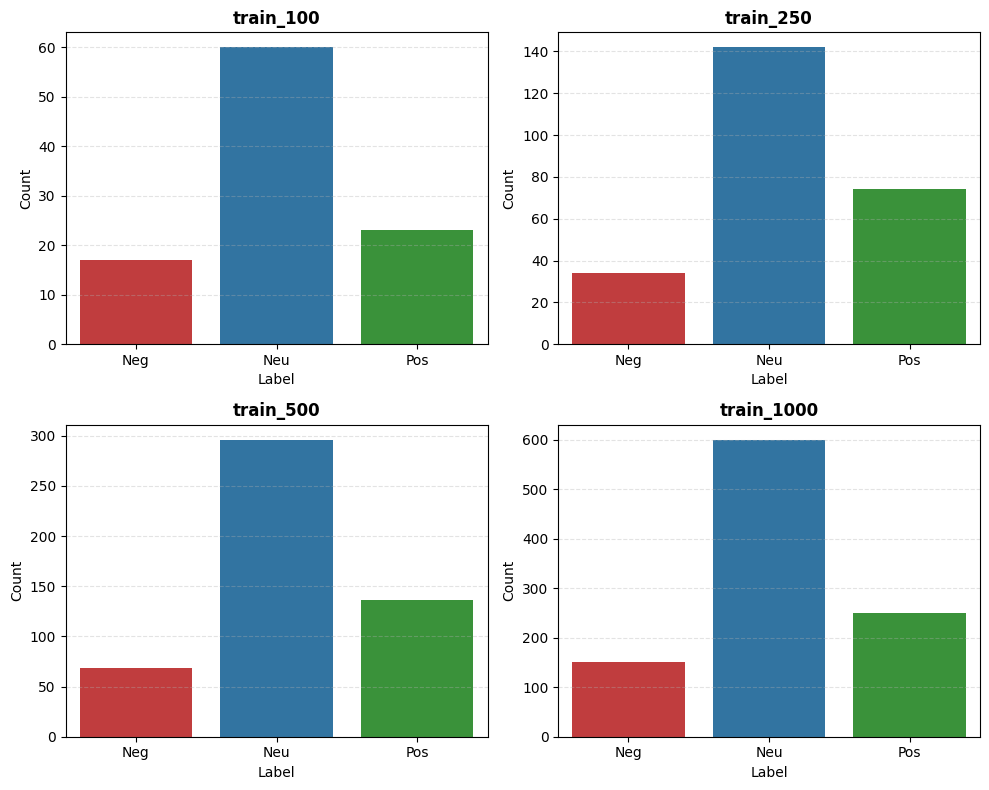

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

label_colors = {
    0: "tab:red",
    1: "tab:blue",
    2: "tab:green",
}

for i, size in enumerate(train_sizes):
    train_df = splits[f"train_{size}"].copy()
    train_df["label"] = train_df["label"].astype(int)

    sns.countplot(
        data=train_df,
        x="label",
        hue="label",
        order=[0, 1, 2],
        hue_order=[0, 1, 2],
        palette=label_colors,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"train_{size}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Label")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(["Neg", "Neu", "Pos"])
    axes[i].grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

#### Result Discussion

The sanity checks confirm that the split construction is correct and consistent. The nested training subsets satisfy the intended hierarchical property, and there is no overlap between training, validation, test, and hidden-pool data. This is important because it prevents information leakage and makes the later comparisons between hard-label and semi-supervised setups methodologically valid.

The class distributions of the two test sets are broadly similar, with **neutral** as the dominant class in both cases. At the same time, `test_disagree` contains a slightly smaller share of **negative** examples and a slightly larger share of **positive** examples than `test_allagree`. These differences are not large, but they should be kept in mind when interpreting later performance gaps between the two test sets.

The bar plots for `train_100`, `train_250`, `train_500`, and `train_1000` show that the same class imbalance is also present in the training data. Because the nested splits preserve this overall structure, the training setup remains consistent across sizes. At the same time, the relatively small number of negative examples helps explain why **negative F1** is a particularly important metric in the later analysis and why weak-labeling gains in the low-label regime are especially relevant for this class.

## 3. Baseline
### 3.1 Baseline Models

As supervised baselines, this notebook compares **DistilBERT** and **ModernBERT**. Both are transformer-based language models, but they differ in their design goals and expected strengths.

* **DistilBERT** is a compact and efficient version of BERT. It was created through knowledge distillation, meaning that it aims to retain much of BERT’s language understanding while using fewer parameters and requiring less computation. In practice, this makes DistilBERT a strong baseline when training time and hardware constraints matter. For this notebook, it is especially useful as a reference model because it is lightweight, widely used, and easy to fine-tune.

* **ModernBERT**, by contrast, represents a newer transformer design. It is intended to be a stronger and more modern encoder baseline, with improved architecture and training choices compared with older BERT-family models. In this notebook, ModernBERT serves as the more powerful comparison model: if it outperforms DistilBERT, that would suggest that the later semi-supervised experiments should build on the stronger backbone rather than on the simpler one.


### 3.2 Epoch Calibration

Before comparing the baseline models, the notebook performs a small **epoch calibration step**. The purpose is to avoid undertraining one backbone which may need another number of epochs than the other one.

For this calibration, **DistilBERT** and **ModernBERT** are both trained on the representative split **`train_500`** for up to **10 epochs**, and their performance is monitored on **`val_allagree`** using **negative F1** as the main criterion. Based on this validation curve, one fixed epoch budget is selected for each model.

This is a **lightweight tuning step**, not a full hyperparameter search. It is only meant to give both backbones a reasonable chance to converge before the main baseline and semi-supervised experiments are run with the selected epoch settings.

In [6]:
from transformers import TrainerCallback

EPOCH_CALIBRATION_TRAIN_SIZE = 500
EPOCH_CALIBRATION_MAX_EPOCHS = 10

epoch_calibration_train_df = splits[
    f"train_{EPOCH_CALIBRATION_TRAIN_SIZE}"
][["sentence", "label"]].copy()
epoch_calibration_results = []


class EpochMetricRecorder(TrainerCallback):
    def __init__(self):
        self.rows = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return

        self.rows.append(
            {
                "epoch": int(round(state.epoch or 0)),
                "accuracy": metrics["eval_accuracy"],
                "macro_f1": metrics["eval_macro_f1"],
                "negative_precision": metrics["eval_negative_precision"],
                "negative_recall": metrics["eval_negative_recall"],
                "negative_f1": metrics["eval_negative_f1"],
            }
        )


for calibration_model_key, calibration_model_name in BASELINE_MODEL_NAMES.items():
    print()
    print(
        f"Calibrating {calibration_model_key} on "
        f"train_{EPOCH_CALIBRATION_TRAIN_SIZE}"
    )

    calibration_classifier = SentimentClassifier(
        model_name=calibration_model_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    calibration_classifier.set_label_mapping(
        SENTIMENT_ID2LABEL,
        SENTIMENT_LABEL2ID,
    )

    calibration_train_dataset = prepare_text_dataset(
        epoch_calibration_train_df,
        calibration_classifier.tokenizer,
    )
    calibration_val_dataset = prepare_text_dataset(
        val_allagree_df,
        calibration_classifier.tokenizer,
    )
    calibration_data_collator = DataCollatorWithPadding(
        tokenizer=calibration_classifier.tokenizer
    )
    epoch_metric_recorder = EpochMetricRecorder()

    calibration_args = create_training_args(
        output_dir=f"models/epoch_calibration_{calibration_model_key}",
        batch_size=16,
        epochs=EPOCH_CALIBRATION_MAX_EPOCHS,
        seed=42,
    )
    if hasattr(calibration_args, "evaluation_strategy"):
        calibration_args.evaluation_strategy = (
            calibration_args.evaluation_strategy.__class__("epoch")
        )
    elif hasattr(calibration_args, "eval_strategy"):
        calibration_args.eval_strategy = calibration_args.eval_strategy.__class__(
            "epoch"
        )
    if hasattr(calibration_args, "do_eval"):
        calibration_args.do_eval = True

    calibration_trainer = Trainer(
        model=calibration_classifier.model,
        args=calibration_args,
        train_dataset=calibration_train_dataset,
        eval_dataset=calibration_val_dataset,
        data_collator=calibration_data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
        callbacks=[epoch_metric_recorder],
    )
    calibration_trainer.train()

    for epoch_row in epoch_metric_recorder.rows:
        epoch_calibration_results.append(
            {
                "model_key": calibration_model_key,
                "model_name": calibration_model_name,
                "train_size": EPOCH_CALIBRATION_TRAIN_SIZE,
                "evaluation_split": "val_allagree",
                **epoch_row,
            }
        )

epoch_calibration_df = pd.DataFrame(epoch_calibration_results).sort_values(
    ["model_key", "epoch"]
).reset_index(drop=True)

selected_epoch_rows = (
    epoch_calibration_df.sort_values(
        ["model_key", "negative_f1", "epoch"],
        ascending=[True, False, True],
    )
    .groupby("model_key", as_index=False)
    .first()
)
selected_epochs_by_model_key = {
    row["model_key"]: int(row["epoch"])
    for _, row in selected_epoch_rows.iterrows()
}
selected_epochs_distilbert = selected_epochs_by_model_key["distilbert"]
selected_epochs_modernbert = selected_epochs_by_model_key["modernbert"]



Calibrating distilbert on train_500


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'eval_loss': '0.6361', 'eval_accuracy': '0.7238', 'eval_macro_f1': '0.464', 'eval_negative_precision': '0', 'eval_negative_recall': '0', 'eval_negative_f1': '0', 'eval_runtime': '0.4474', 'eval_samples_per_second': '404.6', 'eval_steps_per_second': '26.82', 'epoch': '1'}
{'eval_loss': '0.4328', 'eval_accuracy': '0.7845', 'eval_macro_f1': '0.5275', 'eval_negative_precision': '0', 'eval_negative_recall': '0', 'eval_negative_f1': '0', 'eval_runtime': '0.2513', 'eval_samples_per_second': '720.3', 'eval_steps_per_second': '47.76', 'epoch': '2'}
{'eval_loss': '0.3168', 'eval_accuracy': '0.9061', 'eval_macro_f1': '0.8799', 'eval_negative_precision': '0.8', 'eval_negative_recall': '1', 'eval_negative_f1': '0.8889', 'eval_runtime': '0.281', 'eval_samples_per_second': '644.2', 'eval_steps_per_second': '42.71', 'epoch': '3'}
{'eval_loss': '0.267', 'eval_accuracy': '0.9006', 'eval_macro_f1': '0.8627', 'eval_negative_precision': '0.7667', 'eval_negative_recall': '0.9583', 'eval_negative_f1': '0.85

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'eval_loss': '0.6014', 'eval_accuracy': '0.7127', 'eval_macro_f1': '0.491', 'eval_negative_precision': '0.5', 'eval_negative_recall': '0.125', 'eval_negative_f1': '0.2', 'eval_runtime': '0.8998', 'eval_samples_per_second': '201.2', 'eval_steps_per_second': '13.34', 'epoch': '1'}
{'eval_loss': '0.4394', 'eval_accuracy': '0.7735', 'eval_macro_f1': '0.6258', 'eval_negative_precision': '0.6', 'eval_negative_recall': '0.25', 'eval_negative_f1': '0.3529', 'eval_runtime': '0.8009', 'eval_samples_per_second': '226', 'eval_steps_per_second': '14.98', 'epoch': '2'}
{'eval_loss': '0.379', 'eval_accuracy': '0.884', 'eval_macro_f1': '0.8428', 'eval_negative_precision': '0.7273', 'eval_negative_recall': '1', 'eval_negative_f1': '0.8421', 'eval_runtime': '0.8044', 'eval_samples_per_second': '225', 'eval_steps_per_second': '14.92', 'epoch': '3'}
{'eval_loss': '0.5362', 'eval_accuracy': '0.8564', 'eval_macro_f1': '0.7914', 'eval_negative_precision': '0.9333', 'eval_negative_recall': '0.5833', 'eval_ne

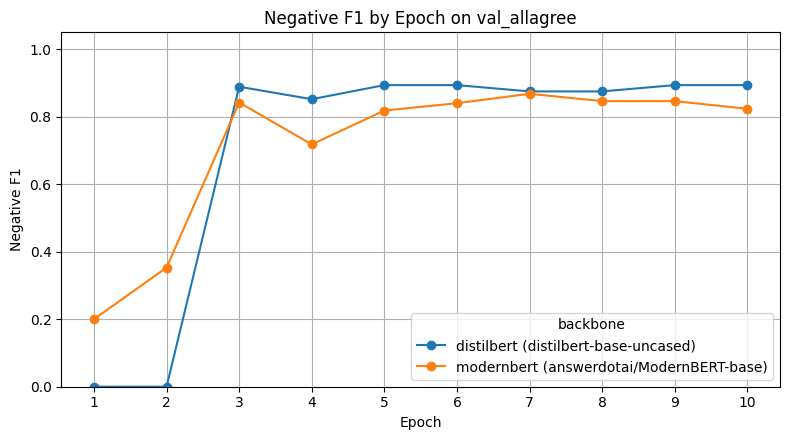

Selected fixed epoch budgets from `val_allagree`: `distilbert = 5`, `modernbert = 7`. The rest of the notebook now reuses these per-model epoch settings.

In [41]:
plt.figure(figsize=(8, 4.5))
for calibration_model_key, calibration_model_name in BASELINE_MODEL_NAMES.items():
    model_curve_df = epoch_calibration_df[
        epoch_calibration_df["model_key"] == calibration_model_key
    ]
    plt.plot(
        model_curve_df["epoch"],
        model_curve_df["negative_f1"],
        marker="o",
        label=f"{calibration_model_key} ({calibration_model_name})",
    )

plt.title("Negative F1 by Epoch on val_allagree")
plt.xlabel("Epoch")
plt.ylabel("Negative F1")
plt.xticks(range(1, EPOCH_CALIBRATION_MAX_EPOCHS + 1))
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(title="backbone")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "Selected fixed epoch budgets from `val_allagree`: "
        f"`distilbert = {selected_epochs_distilbert}`, "
        f"`modernbert = {selected_epochs_modernbert}`. "
        "The rest of the notebook now reuses these per-model epoch settings."
    )
)


#### Result Discussion

The epoch calibration shows that the two backbones converge differently on the negative class. ModernBERT already achieves a useful negative F1 after the first few epochs and improves more gradually, while DistilBERT starts with 0.00 negative F1 in the first two epochs and only becomes competitive from epoch 3 onward.

On `val_allagree`, DistilBERT reaches its best negative F1 of **0.8936** already at **epoch 5** and then stays at a very similar level, whereas ModernBERT peaks later at **epoch 7** with **0.8679**.

The calibration supports the use of **model-specific fixed epoch budgets** in the rest of the notebook: **5 epochs for DistilBERT** and **7 epochs for ModernBERT**.

### 3.3 Baseline Comparison

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.13.31.png" alt="" width="60%">
</div>


The baseline comparison is designed as a controlled supervised experiment in which both transformer backbones are trained under the same conditions and then evaluated on the same fixed splits.

For this first comparison, both models are trained on the largest clean hard-label split, **`train_1000`**, which contains only examples from the **100% agreement subset**. Each backbone now uses the fixed epoch budget selected in the previous calibration step on **`val_allagree`**. This keeps the later comparison simple while giving both models a reasonable chance to converge.

After training, each model is evaluated on three fixed datasets:

- **`val_allagree`**: used as the development set for the earlier epoch calibration and later light model-selection choices
- **`test_allagree`**: the main clean benchmark, containing only 100%-agreement examples
- **`test_disagree`**: the harder robustness benchmark, containing examples from lower-agreement subsets

This separation is important. The validation set is used to support development decisions without contaminating the test sets, while the two test sets make it possible to compare performance on **clean labels** versus **more ambiguous labels**.

The reported metrics include **accuracy**, **macro-F1**, **negative precision**, **negative recall**, and **negative F1**. Among these, **negative F1** is the main decision metric, because the negative class is both the smallest and one of the most important classes in practice. A model that performs well overall but fails to identify negative sentiment reliably would be less useful for the purposes of this task.

In [9]:
baseline_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

baseline_results = []
baseline_train_sizes = train_sizes

# This loop builds the hard-label baseline learning curves for both backbones.
for baseline_model_key, baseline_model_name in BASELINE_MODEL_NAMES.items():
    selected_epochs = selected_epochs_by_model_key[baseline_model_key]

    print()
    print(
        f"=== Baseline learning curve: {baseline_model_key} "
        f"({baseline_model_name}, {selected_epochs} epochs) ==="
    )

    for baseline_train_size in baseline_train_sizes:
        print(
            f"Training {baseline_model_key} on train_{baseline_train_size} "
            f"for {selected_epochs} epochs"
        )
        baseline_train_df = splits[f"train_{baseline_train_size}"]

        baseline_classifier = SentimentClassifier(
            model_name=baseline_model_name,
            num_labels=len(SENTIMENT_ID2LABEL),
        )
        baseline_classifier.set_label_mapping(
            SENTIMENT_ID2LABEL,
            SENTIMENT_LABEL2ID,
        )

        train_dataset = prepare_text_dataset(
            baseline_train_df,
            baseline_classifier.tokenizer,
        )
        val_dataset = prepare_text_dataset(
            val_allagree_df,
            baseline_classifier.tokenizer,
        )
        data_collator = DataCollatorWithPadding(tokenizer=baseline_classifier.tokenizer)

        baseline_trainer = Trainer(
            model=baseline_classifier.model,
            args=create_training_args(
                output_dir=f"models/{baseline_model_key}_{baseline_train_size}",
                batch_size=16,
                epochs=selected_epochs,
                seed=42,
            ),
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=lambda eval_pred: compute_metrics(
                eval_pred,
                negative_label=NEGATIVE_LABEL,
            ),
        )

        baseline_trainer.train()

        for evaluation_split_name, evaluation_split_df in baseline_eval_splits.items():
            evaluation_dataset = prepare_text_dataset(
                evaluation_split_df,
                baseline_classifier.tokenizer,
            )
            evaluation_predictions = baseline_trainer.predict(evaluation_dataset)
            evaluation_metrics = compute_metrics(
                (
                    evaluation_predictions.predictions,
                    evaluation_predictions.label_ids,
                ),
                negative_label=NEGATIVE_LABEL,
            )

            baseline_results.append(
                {
                    "model_key": baseline_model_key,
                    "model_name": baseline_model_name,
                    "epochs": selected_epochs,
                    "train_size": baseline_train_size,
                    "evaluation_split": evaluation_split_name,
                    **evaluation_metrics,
                }
            )

print(f"Collected {len(baseline_results)} baseline evaluation rows.")



=== Baseline learning curve: distilbert (distilbert-base-uncased, 5 epochs) ===
Training distilbert on train_100 for 5 epochs


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'train_runtime': '2.936', 'train_samples_per_second': '170.3', 'train_steps_per_second': '11.92', 'train_loss': '0.9628', 'epoch': '5'}
Training distilbert on train_250 for 5 epochs


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'train_runtime': '6.981', 'train_samples_per_second': '179.1', 'train_steps_per_second': '11.46', 'train_loss': '0.6984', 'epoch': '5'}
Training distilbert on train_500 for 5 epochs


...

{'train_runtime': '25.58', 'train_samples_per_second': '68.41', 'train_steps_per_second': '4.378', 'train_loss': '0.2909', 'epoch': '7'}
Training modernbert on train_500 for 7 epochs


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '50.54', 'train_samples_per_second': '69.25', 'train_steps_per_second': '4.432', 'train_loss': '0.1729', 'epoch': '7'}
Training modernbert on train_1000 for 7 epochs


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '99.57', 'train_samples_per_second': '70.3', 'train_steps_per_second': '4.429', 'train_loss': '0.1162', 'epoch': '7'}
Collected 24 baseline evaluation rows.


In [10]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    [
        "model_key",
        "model_name",
        "train_size",
        "evaluation_split",
        "negative_f1",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
    ]
].sort_values(
    ["evaluation_split", "model_key", "train_size"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(
    baseline_results_df.style.format(
        {
            "negative_f1": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"])
)

,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,distilbert,distilbert-base-uncased,100,test_allagree,0.0000,0.6128,0.2533,0.0000,0.0000
1,distilbert,distilbert-base-uncased,250,test_allagree,0.0000,0.7655,0.5216,0.0000,0.0000
2,distilbert,distilbert-base-uncased,500,test_allagree,0.8852,0.9270,0.9043,0.8852,0.8852
3,distilbert,distilbert-base-uncased,1000,test_allagree,0.9091,0.9535,0.9352,0.9167,0.9016
4,modernbert,answerdotai/ModernBERT-base,100,test_allagree,0.4823,0.7500,0.6524,0.4250,0.5574
5,modernbert,answerdotai/ModernBERT-base,250,test_allagree,0.8527,0.9004,0.8731,0.8088,0.9016
6,modernbert,answerdotai/ModernBERT-base,500,test_allagree,0.9333,0.9447,0.9316,0.9492,0.9180
7,modernbert,answerdotai/ModernBERT-base,1000,test_allagree,0.9302,0.9624,0.9499,0.8824,0.9836
8,distilbert,distilbert-base-uncased,100,test_disagree,0.0000,0.5756,0.2435,0.0000,0.0000
9,distilbert,distilbert-base-uncased,250,test_disagree,0.0000,0.5640,0.3311,0.0000,0.0000


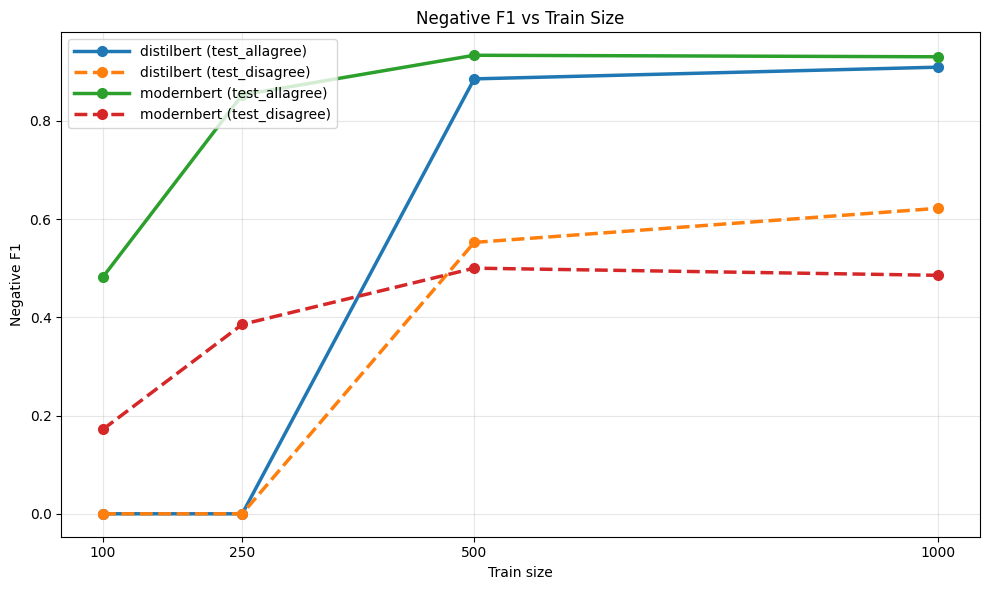

In [11]:
plot_df = baseline_results_df[
    baseline_results_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()

split_styles = {
    "test_allagree": "-",
    "test_disagree": "--"
}

plt.figure(figsize=(10, 6))

for baseline_model_key in BASELINE_MODEL_NAMES:
    for split_name in ["test_allagree", "test_disagree"]:
        model_results_df = plot_df[
            (plot_df["model_key"] == baseline_model_key) &
            (plot_df["evaluation_split"] == split_name)
        ].sort_values("train_size")

        plt.plot(
            model_results_df["train_size"],
            model_results_df["negative_f1"],
            marker="o",
            linestyle=split_styles[split_name],
            linewidth=2.5,
            markersize=7,
            label=f"{baseline_model_key} ({split_name})"
        )

plt.title("Negative F1 vs Train Size")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", frameon=True, handlelength=4)
plt.tight_layout()
plt.show()

#### Result Discussion

**ModernBERT** is clearly stronger in the **low-label regime**: at `train_100` and `train_250`, it already achieves substantial negative-class performance on both `val_allagree` and `test_allagree`, whereas **DistilBERT** still fails to identify the negative class and remains at **0.00 negative F1**. This suggests that ModernBERT is much more data-efficient when only a small number of clean labels is available.

From `train_500` onward, however, the picture becomes more balanced. On the clean splits, both models perform very strongly, with ModernBERT retaining a slight advantage overall. On `test_allagree`, for example, ModernBERT reaches about **0.93 negative F1** at both `train_500` and `train_1000`, while DistilBERT rises sharply to about **0.89** and **0.91**.

The results on `test_disagree` are lower for both backbones, which is expected because this split contains more ambiguous examples. Here the pattern is more mixed: ModernBERT performs better at smaller train sizes, but **DistilBERT overtakes it at `train_500` and `train_1000`**. This indicates that the stronger clean-label performance of ModernBERT does not automatically translate into better robustness on lower-agreement data.

Overall, the baseline section supports two conclusions. First, **ModernBERT is the better practical backbone for the main notebook pipeline**, because it performs much better when labeled data is scarce and remains strongest on the clean benchmark splits. Second, the gap between `test_allagree` and `test_disagree` confirms that annotator disagreement corresponds to a genuinely harder classification setting, not just a different random sample of the same task.

## 4. Weak Labeling

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.13.48.png" alt="" width="60%">
</div>


### 4.1 Embeddings Models and k-NN

The next part of the notebook moves from purely supervised learning to a **weak-labeling setup**. The core idea is to use a relatively small set of reliable hard labels as a **seed set**, represent the texts in an embedding space, and then assign labels to previously hidden examples based on their nearest labeled neighbors. This creates additional **weak labels**, which can later be used for semi-supervised retraining.

The motivation for this step is closely tied to the main challenge question: if good weak labels can be generated from a limited number of manually labeled examples, then the classifier may achieve competitive performance with substantially less human annotation effort.

To make this process explicit, the notebook compares two different embedding strategies:

- **SBERT**, a sentence-transformer model designed for sentence-level semantic similarity
- **plain BERT with mean pooling**, included as a comparison baseline that is not specifically optimized for sentence embeddings

This comparison is important because k-NN weak labeling depends directly on the quality of the embedding space. If semantically similar texts are placed close together, nearest-neighbor label transfer becomes more reliable. For that reason, the notebook first evaluates the embedding models themselves before using them for weak labeling.

The weak-labeling procedure in this notebook is deliberately simple and transparent:

- the labeled seed set comes from the **high-agreement training data**
- the target set for weak labeling is the fixed **`hidden_allagree_pool`**
- labels are generated with **k-nearest neighbors**
- both **majority vote** and **distance-weighted vote** are compared
- performance is evaluated directly against the hidden true labels before any downstream retraining is performed

In [12]:
SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BERT_MODEL_NAME = "bert-base-uncased"
EMBEDDING_BATCH_SIZE = 32

print("SBERT model:", SBERT_MODEL_NAME)
print("Plain BERT model:", BERT_MODEL_NAME)
print("Embedding batch size:", EMBEDDING_BATCH_SIZE)


SBERT model: sentence-transformers/all-MiniLM-L6-v2
Plain BERT model: bert-base-uncased
Embedding batch size: 32


In [13]:
embedding_device = get_device()

sbert_model = SentenceTransformer(
    SBERT_MODEL_NAME,
    device=str(embedding_device),
)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.to(embedding_device)
bert_model.eval()


def encode_with_plain_bert(sentences, batch_size=EMBEDDING_BATCH_SIZE):
    """Plain BERT baseline: mean-pool token embeddings with the attention mask."""
    pooled_batches = []

    for start in range(0, len(sentences), batch_size):
        batch_sentences = sentences[start : start + batch_size]
        batch = bert_tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        batch = {
            name: tensor.to(embedding_device)
            for name, tensor in batch.items()
        }

        with torch.no_grad():
            outputs = bert_model(**batch)

        # Mean pooling keeps the plain BERT baseline comparable to the sentence model.
        token_embeddings = outputs.last_hidden_state
        attention_mask = batch["attention_mask"].unsqueeze(-1)
        summed_embeddings = (token_embeddings * attention_mask).sum(dim=1)
        token_counts = attention_mask.sum(dim=1).clamp(min=1)
        pooled_embeddings = summed_embeddings / token_counts
        pooled_batches.append(pooled_embeddings.cpu().numpy())

    return np.vstack(pooled_batches)


print("Embedding device:", embedding_device)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding device: mps


### 4.2 Embedding Setup

To keep the comparison controlled, the embedding models are applied to the same agreement-aware data splits. The labeled seed data comes from the clean hard-label training pool, while the target set for weak labeling is the fixed **`hidden_allagree_pool`**. This hidden pool is especially useful because its true labels are known for evaluation, even though they are hidden during the weak-labeling step itself.

Using the same seed and target structure for both embedding models ensures that any later performance differences can be attributed mainly to the embedding quality rather than to changes in the data setup.

In [14]:
# Build both embedding corpora once so later cells can reuse the same arrays.
embedding_train_df = splits["hard_label_train_pool"].copy()
embedding_hidden_df = splits["hidden_allagree_pool"].copy()

embedding_train_texts = embedding_train_df["sentence"].tolist()
embedding_train_labels = embedding_train_df["label"].to_numpy()
embedding_hidden_texts = embedding_hidden_df["sentence"].tolist()
embedding_hidden_labels = embedding_hidden_df["label"].to_numpy()

embedding_counts_df = pd.DataFrame(
    [
        {
            "split": "hard_label_train_pool",
            "rows": len(embedding_train_df),
            "label_source": "observed hard labels",
        },
        {
            "split": "hidden_allagree_pool",
            "rows": len(embedding_hidden_df),
            "label_source": "hidden clean labels for later offline checks",
        },
    ]
)

display(embedding_counts_df)


,split,rows,label_source
0,hard_label_train_pool,1000,observed hard labels
1,hidden_allagree_pool,626,hidden clean labels for later offline checks


In [15]:
sbert_train_embeddings = sbert_model.encode(
    embedding_train_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BARS,
)

sbert_hidden_embeddings = sbert_model.encode(
    embedding_hidden_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BARS,
)

print("sbert_train_embeddings shape:", sbert_train_embeddings.shape)
print("sbert_hidden_embeddings shape:", sbert_hidden_embeddings.shape)


sbert_train_embeddings shape: (1000, 384)
sbert_hidden_embeddings shape: (626, 384)


In [16]:
bert_train_embeddings = encode_with_plain_bert(embedding_train_texts)
bert_hidden_embeddings = encode_with_plain_bert(embedding_hidden_texts)

print("bert_train_embeddings shape:", bert_train_embeddings.shape)
print("bert_hidden_embeddings shape:", bert_hidden_embeddings.shape)


bert_train_embeddings shape: (1000, 768)
bert_hidden_embeddings shape: (626, 768)


In [17]:
embedding_shapes_df = pd.DataFrame(
    [
        {
            "model": "SBERT",
            "model_name": SBERT_MODEL_NAME,
            "train_shape": tuple(sbert_train_embeddings.shape),
            "hidden_shape": tuple(sbert_hidden_embeddings.shape),
        },
        {
            "model": "BERT mean pool",
            "model_name": BERT_MODEL_NAME,
            "train_shape": tuple(bert_train_embeddings.shape),
            "hidden_shape": tuple(bert_hidden_embeddings.shape),
        },
    ]
)

display(embedding_shapes_df)

# Slice all nested seed sets from the same full clean embedding pool.
train_embedding_positions_by_size = {
    size: embedding_train_df.index.get_indexer(splits[f"train_{size}"].index)
    for size in train_sizes
}

sbert_train_embeddings_by_size = {
    size: sbert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
bert_train_embeddings_by_size = {
    size: bert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
train_texts_by_size = {
    size: splits[f"train_{size}"]["sentence"].tolist()
    for size in train_sizes
}
train_labels_by_size = {
    size: splits[f"train_{size}"]["label"].to_numpy()
    for size in train_sizes
}

embedding_artifacts = {
    "train_df": embedding_train_df,
    "hidden_df": embedding_hidden_df,
    "train_texts": embedding_train_texts,
    "train_labels": embedding_train_labels,
    "hidden_texts": embedding_hidden_texts,
    "hidden_labels": embedding_hidden_labels,
    "train_positions_by_size": train_embedding_positions_by_size,
    "train_texts_by_size": train_texts_by_size,
    "train_labels_by_size": train_labels_by_size,
    "sbert": {
        "model_name": SBERT_MODEL_NAME,
        "train_embeddings": sbert_train_embeddings,
        "hidden_embeddings": sbert_hidden_embeddings,
        "train_embeddings_by_size": sbert_train_embeddings_by_size,
    },
    "bert": {
        "model_name": BERT_MODEL_NAME,
        "train_embeddings": bert_train_embeddings,
        "hidden_embeddings": bert_hidden_embeddings,
        "train_embeddings_by_size": bert_train_embeddings_by_size,
    },
}


,model,model_name,train_shape,hidden_shape
0,SBERT,sentence-transformers/all-MiniLM-L6-v2,"(1000, 384)","(626, 384)"
1,BERT mean pool,bert-base-uncased,"(1000, 768)","(626, 768)"


### 4.3 Embedding Quality Diagnostics

Before generating weak labels, the notebook first checks whether the embedding spaces look suitable for semantic label transfer. This is done with a set of simple diagnostics that examine how well the embeddings separate the sentiment classes before any k-NN labeling is applied.

Several complementary views are used:

- **Class-wise cosine similarity** compares how similar embeddings are **within the same class** and **across different classes**. A useful embedding space should show higher similarity among sentences with the same sentiment than among sentences from different sentiment classes.
- **Nearest-neighbor purity** measures how often the closest neighbor of a labeled example has the **same label**. This gives a direct first indication of whether local neighborhoods in embedding space are label-consistent, which is especially relevant for later k-NN weak labeling.
- **Centroid comparisons** summarize each class by its mean embedding and then compare the class centroids to one another. This provides a simple global view of how strongly the sentiment classes are separated overall.
- **UMAP** projects the high-dimensional embeddings into two dimensions for visualization. This does not preserve all distances perfectly, but it is useful for seeing whether the classes form visibly distinct clusters or whether they overlap strongly.

In [18]:
embedding_sets = {
    "SBERT": sbert_train_embeddings,
    "BERT mean pool": bert_train_embeddings,
}

similarity_rows = []
nn_rows = []
centroid_similarity_tables = {}

# These cheap diagnostics check whether the neighborhood structure looks useful for k-NN.
for model_label, embeddings in embedding_sets.items():
    normalized_embeddings = embeddings / np.clip(
        np.linalg.norm(embeddings, axis=1, keepdims=True),
        a_min=1e-12,
        a_max=None,
    )

    cosine_matrix = normalized_embeddings @ normalized_embeddings.T
    same_label_mask = (
        embedding_train_labels[:, None] == embedding_train_labels[None, :]
    )
    diagonal_mask = np.eye(len(embedding_train_labels), dtype=bool)

    intra_class_values = cosine_matrix[same_label_mask & ~diagonal_mask]
    inter_class_values = cosine_matrix[~same_label_mask]

    similarity_rows.append(
        {
            "model": model_label,
            "mean_intra_class_cosine": intra_class_values.mean(),
            "mean_inter_class_cosine": inter_class_values.mean(),
            "similarity_gap": intra_class_values.mean() - inter_class_values.mean(),
        }
    )

    leave_one_out_matrix = cosine_matrix.copy()
    np.fill_diagonal(leave_one_out_matrix, -np.inf)
    nearest_neighbor_indices = leave_one_out_matrix.argmax(axis=1)
    nearest_neighbor_labels = embedding_train_labels[nearest_neighbor_indices]
    nn_rows.append(
        {
            "model": model_label,
            "leave_one_out_1nn_purity": (
                nearest_neighbor_labels == embedding_train_labels
            ).mean(),
        }
    )

    centroid_vectors = {}
    centroid_order = [
        SENTIMENT_ID2LABEL[label_id]
        for label_id in sorted(SENTIMENT_ID2LABEL)
    ]
    for label_id, label_name in SENTIMENT_ID2LABEL.items():
        class_embeddings = normalized_embeddings[embedding_train_labels == label_id]
        centroid = class_embeddings.mean(axis=0)
        centroid = centroid / np.clip(np.linalg.norm(centroid), a_min=1e-12, a_max=None)
        centroid_vectors[label_name] = centroid

    centroid_table = pd.DataFrame(
        index=centroid_order,
        columns=centroid_order,
        dtype=float,
    )
    for row_label in centroid_order:
        for col_label in centroid_order:
            centroid_table.loc[row_label, col_label] = float(
                centroid_vectors[row_label] @ centroid_vectors[col_label]
            )
    centroid_similarity_tables[model_label] = centroid_table.round(3)

embedding_similarity_df = pd.DataFrame(similarity_rows).round(3)
embedding_nn_purity_df = pd.DataFrame(nn_rows).round(3)
embedding_quality_df = embedding_similarity_df.merge(
    embedding_nn_purity_df,
    on="model",
)

display(embedding_quality_df)

for model_label, centroid_table in centroid_similarity_tables.items():
    print()
    print(f"{model_label} centroid cosine similarity")
    display(centroid_table)


,model,mean_intra_class_cosine,mean_inter_class_cosine,similarity_gap,leave_one_out_1nn_purity
0,SBERT,0.159,0.158,0.001,0.775
1,BERT mean pool,0.641,0.654,-0.013,0.778



SBERT centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.615,0.862
neutral,0.615,1.000,0.759
positive,0.862,0.759,1.000



BERT mean pool centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.928,0.991
neutral,0.928,1.000,0.947
positive,0.991,0.947,1.000


#### UMAP Visualization of Seed Embeddings

As a lightweight bonus check, the next cell projects the `train_1000` seed embeddings into two dimensions. The goal is not to replace the quantitative diagnostics above, but to add a visual comparison between SBERT and plain BERT before the k-NN weak-labeling step.


In [42]:
umap_seed_size = max(train_sizes)
umap_seed_labels = train_labels_by_size[umap_seed_size]
umap_seed_label_names = pd.Series(umap_seed_labels).map(SENTIMENT_ID2LABEL).to_numpy()
umap_model_order = ["SBERT", "BERT mean pool"]
umap_projection_by_model = {}
umap_projection_rows = []
umap_projection_quality_rows = []

if not UMAP_AVAILABLE:
    print(f"UMAP is unavailable in this environment: {UMAP_IMPORT_ERROR}")
    umap_projection_df = pd.DataFrame()
    umap_projection_quality_df = pd.DataFrame()
else:
    umap_embedding_sets = {
        "SBERT": sbert_train_embeddings_by_size[umap_seed_size],
        "BERT mean pool": bert_train_embeddings_by_size[umap_seed_size],
    }

    for model_label, embeddings in umap_embedding_sets.items():
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            random_state=42,
            n_jobs=1,
        )
        projection = reducer.fit_transform(embeddings)
        umap_projection_by_model[model_label] = projection

        projection_df = pd.DataFrame(
            {
                "umap_1": projection[:, 0],
                "umap_2": projection[:, 1],
                "label_id": umap_seed_labels,
                "label_name": umap_seed_label_names,
                "model": model_label,
            }
        )
        umap_projection_rows.append(projection_df)

        # This is only a visual sanity check, so we keep the summary metrics simple.
        distance_matrix = np.sqrt(
            ((projection[:, None, :] - projection[None, :, :]) ** 2).sum(axis=-1)
        )
        same_label_mask = umap_seed_labels[:, None] == umap_seed_labels[None, :]
        diagonal_mask = np.eye(len(umap_seed_labels), dtype=bool)
        intra_class_distance = distance_matrix[same_label_mask & ~diagonal_mask].mean()
        inter_class_distance = distance_matrix[~same_label_mask].mean()

        projected_neighbor_search = NearestNeighbors(n_neighbors=2)
        projected_neighbor_search.fit(projection)
        _, projected_neighbor_indices = projected_neighbor_search.kneighbors(projection)
        projected_neighbor_labels = umap_seed_labels[projected_neighbor_indices[:, 1]]
        projected_1nn_purity = (projected_neighbor_labels == umap_seed_labels).mean()

        umap_projection_quality_rows.append(
            {
                "model": model_label,
                "mean_intra_class_distance_2d": intra_class_distance,
                "mean_inter_class_distance_2d": inter_class_distance,
                "distance_gap_2d": inter_class_distance - intra_class_distance,
                "projected_1nn_purity": projected_1nn_purity,
            }
        )

    umap_projection_df = pd.concat(umap_projection_rows, ignore_index=True)
    umap_projection_quality_df = pd.DataFrame(umap_projection_quality_rows).round(3)
    display(umap_projection_quality_df)


,model,mean_intra_class_distance_2d,mean_inter_class_distance_2d,distance_gap_2d,projected_1nn_purity
0,SBERT,2.723,3.754,1.031,0.745
1,BERT mean pool,2.822,3.659,0.838,0.675


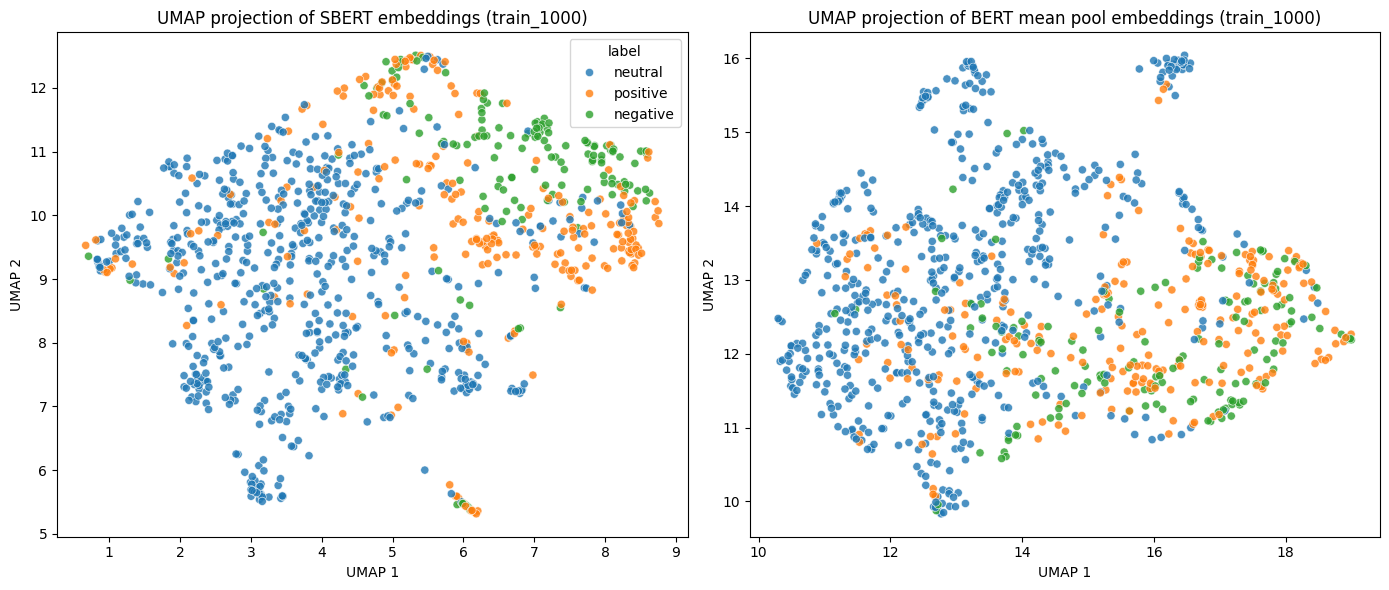

In [21]:
if not UMAP_AVAILABLE:
    print(f"UMAP is unavailable in this environment: {UMAP_IMPORT_ERROR}")
elif umap_projection_df.empty:
    print("No UMAP projection data is available to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, model_label in zip(axes, umap_model_order):
        projection_df = umap_projection_df[
            umap_projection_df["model"] == model_label
        ]

        sns.scatterplot(
            data=projection_df,
            x="umap_1",
            y="umap_2",
            hue="label_name",
            s=35,
            alpha=0.8,
            ax=ax,
        )
        ax.set_title(
            f"UMAP projection of {model_label} embeddings (train_{umap_seed_size})"
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        if ax is axes[0]:
            ax.legend(title="label")
        else:
            ax.legend_.remove()

    plt.tight_layout()
    plt.show()


#### Result Discussion

The embedding diagnostics already suggest that **SBERT** is the better basis for k-NN weak labeling, even before any weak labels are generated. In the original embedding space, the two models have very similar **leave-one-out 1-NN purity** values (**0.775** for SBERT vs. **0.778** for BERT mean pooling), so purely local nearest-neighbor consistency looks comparable at first glance. However, the other diagnostics show an important qualitative difference: **SBERT separates the class centroids much more clearly**, while BERT mean pooling keeps them much closer together.

This is especially visible in the centroid cosine tables. For **SBERT**, the negative centroid is clearly less similar to the neutral centroid (**0.615**) than to itself, and the overall off-diagonal similarities are meaningfully lower. For **BERT mean pooling**, by contrast, all three class centroids are extremely close to each other, with cosine similarities between **0.928** and **0.991**. That suggests a much less discriminative global embedding structure, even if some local neighbors are still label-consistent.

The UMAP projection supports the same interpretation. In the **SBERT** plot, the classes show a more visible large-scale organization, whereas in the **BERT mean pool** projection the classes overlap more strongly. This is also reflected in the 2D distance diagnostics: SBERT achieves a larger **distance gap** (**1.031** vs. **0.838**) and a higher projected 1-NN purity (**0.745** vs. **0.675**). Since UMAP is only a projection, these numbers should not be overinterpreted, but they are consistent with the visual impression.

Overall, the diagnostics suggest that **SBERT provides the more useful embedding space for semantic label transfer**. Even though the raw 1-NN purity in the original space is similar for both models, SBERT shows better class-level separation and a more interpretable geometric structure. That makes it the more promising candidate for the following k-NN weak-labeling step.

### 4.4 Weak-Label Generation

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.14.06.png" alt="" width="60%">
</div>



Next step is to use the embeddings for actual **weak-label generation**. The idea is simple: each example in the fixed **`hidden_allagree_pool`** receives a label from its nearest labeled neighbors in the embedding space of the seed set.

The notebook compares:

- two embedding models:
  - **SBERT**
  - **BERT mean pooling**
- several neighborhood sizes:
  - **\(k = 3, 5, 11\)**
- two voting rules:
  - **majority vote**
  - **distance-weighted vote**

In **majority vote**, the hidden example receives the label that appears most often among its \(k\) nearest neighbors. In **distance-weighted vote**, neighbors that are closer in embedding space receive a higher weight than more distant ones, so that very similar seed examples influence the assigned weak label more strongly.

This comparison is important because weak-label quality depends on more than just the embedding model. Even with a good embedding space, the chosen neighborhood size and voting rule can affect whether the generated labels are stable, noisy, or biased toward the dominant class.

The generated weak labels are evaluated **directly** against the hidden true labels of `hidden_allagree_pool`.

In [22]:
WEAK_LABEL_K_VALUES = [3, 5, 11]
WEAK_LABEL_VOTE_MODES = ["majority_vote", "distance_weighted"]
WEAK_LABEL_SEED_SIZE = max(train_sizes)

weak_label_seed_df = splits[f"train_{WEAK_LABEL_SEED_SIZE}"].copy()
weak_label_hidden_df = splits["hidden_allagree_pool"].copy()
weak_label_hidden_true_labels = weak_label_hidden_df["label"].to_numpy()

weak_label_embedding_sets = {
    "SBERT": {
        "seed_embeddings": sbert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": sbert_hidden_embeddings,
    },
    "BERT mean pool": {
        "seed_embeddings": bert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": bert_hidden_embeddings,
    },
}


def predict_knn_labels(
    train_embeddings,
    train_labels,
    query_embeddings,
    k,
    vote_mode="majority_vote",
    epsilon=1e-8,
):
    """Use cosine neighbors with either majority voting or inverse-distance weighting."""
    neighbor_search = NearestNeighbors(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute",
    )
    neighbor_search.fit(train_embeddings)
    distances, neighbor_indices = neighbor_search.kneighbors(query_embeddings)
    neighbor_labels = train_labels[neighbor_indices]

    predicted_labels = []
    confidence_scores = []
    for row_labels, row_distances in zip(neighbor_labels, distances):
        if np.any(row_distances <= epsilon):
            zero_distance_labels = row_labels[row_distances <= epsilon]
            label_scores = np.bincount(
                zero_distance_labels,
                minlength=len(SENTIMENT_ID2LABEL),
            ).astype(float)
        elif vote_mode == "distance_weighted":
            # Closer neighbors get more influence than farther ones.
            weights = 1.0 / np.maximum(row_distances, epsilon)
            label_scores = np.bincount(
                row_labels,
                weights=weights,
                minlength=len(SENTIMENT_ID2LABEL),
            )
        elif vote_mode == "majority_vote":
            # Each of the k neighbors contributes one vote.
            label_scores = np.bincount(
                row_labels,
                minlength=len(SENTIMENT_ID2LABEL),
            ).astype(float)
        else:
            raise ValueError(f"Unsupported vote_mode: {vote_mode}")

        predicted_label = int(label_scores.argmax())
        predicted_labels.append(predicted_label)
        confidence_scores.append(label_scores[predicted_label] / label_scores.sum())

    return (
        np.array(predicted_labels),
        neighbor_indices,
        distances,
        np.array(confidence_scores),
    )


weak_label_results = []
weak_label_predictions = {}
weak_label_confusion_matrices = {}

# Keep the hidden clean pool fixed so the weak-label comparison stays fair.
for embedding_name, embedding_values in weak_label_embedding_sets.items():
    seed_embeddings = embedding_values["seed_embeddings"]
    hidden_embeddings = embedding_values["hidden_embeddings"]
    seed_labels = train_labels_by_size[WEAK_LABEL_SEED_SIZE]

    for vote_mode in WEAK_LABEL_VOTE_MODES:
        for k in WEAK_LABEL_K_VALUES:
            (
                predicted_labels,
                neighbor_indices,
                neighbor_distances,
                confidence_scores,
            ) = predict_knn_labels(
                train_embeddings=seed_embeddings,
                train_labels=seed_labels,
                query_embeddings=hidden_embeddings,
                k=k,
                vote_mode=vote_mode,
            )

            predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
            metrics = compute_metrics(
                (predicted_logits, weak_label_hidden_true_labels),
                negative_label=NEGATIVE_LABEL,
            )
            confusion = compute_confusion_matrix(
                true_labels=weak_label_hidden_true_labels,
                predicted_labels=predicted_labels,
                label_order=sorted(SENTIMENT_ID2LABEL),
            )

            setting_key = f"{embedding_name} | {vote_mode} | k={k}"
            weak_labeled_hidden_setting_df = weak_label_hidden_df.copy()
            weak_labeled_hidden_setting_df["true_label"] = weak_label_hidden_true_labels
            weak_labeled_hidden_setting_df["label"] = predicted_labels
            weak_labeled_hidden_setting_df["weak_label"] = predicted_labels
            weak_labeled_hidden_setting_df["weak_label_confidence"] = confidence_scores
            weak_labeled_hidden_setting_df["embedding_name"] = embedding_name
            weak_labeled_hidden_setting_df["vote_mode"] = vote_mode
            weak_labeled_hidden_setting_df["k"] = k
            weak_labeled_hidden_setting_df["is_weak"] = True
            weak_labeled_hidden_setting_df["prediction_correct"] = (
                predicted_labels == weak_label_hidden_true_labels
            )

            weak_label_results.append(
                {
                    "embedding_name": embedding_name,
                    "vote_mode": vote_mode,
                    "k": k,
                    "seed_size": WEAK_LABEL_SEED_SIZE,
                    **metrics,
                    "mean_vote_confidence": confidence_scores.mean(),
                }
            )
            weak_label_predictions[setting_key] = {
                "predicted_labels": predicted_labels,
                "neighbor_indices": neighbor_indices,
                "neighbor_distances": neighbor_distances,
                "confidence_scores": confidence_scores,
                "weak_labeled_hidden_df": weak_labeled_hidden_setting_df,
            }
            weak_label_confusion_matrices[setting_key] = confusion

print(f"Seed split used for weak labeling: train_{WEAK_LABEL_SEED_SIZE}")
print(f"Compared settings: {len(weak_label_results)}")


Seed split used for weak labeling: train_1000
Compared settings: 12


The next table shows direct weak-label quality on the fixed `hidden_allagree_pool` for each embedding, vote mode, and `k`.

In [23]:
weak_label_results_df = pd.DataFrame(weak_label_results)
weak_label_results_df = weak_label_results_df[
    [
        "embedding_name",
        "vote_mode",
        "k",
        "seed_size",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["embedding_name", "vote_mode", "k"]).reset_index(drop=True)

metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
    "mean_vote_confidence",
]

display(
    weak_label_results_df.style.format(
        {column: "{:.3f}" for column in metric_columns}
    ).highlight_max(
        subset=["negative_f1"],
    )
)


,embedding_name,vote_mode,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
0,BERT mean pool,distance_weighted,3,1000,0.789,0.677,0.429,0.485,0.455,0.837
1,BERT mean pool,distance_weighted,5,1000,0.805,0.701,0.493,0.515,0.504,0.801
2,BERT mean pool,distance_weighted,11,1000,0.810,0.699,0.545,0.441,0.488,0.760
3,BERT mean pool,majority_vote,3,1000,0.773,0.659,0.355,0.485,0.410,0.834
4,BERT mean pool,majority_vote,5,1000,0.812,0.702,0.446,0.544,0.490,0.798
5,BERT mean pool,majority_vote,11,1000,0.808,0.693,0.484,0.456,0.470,0.755
6,SBERT,distance_weighted,3,1000,0.850,0.785,0.646,0.779,0.707,0.860
7,SBERT,distance_weighted,5,1000,0.866,0.800,0.676,0.735,0.704,0.833
8,SBERT,distance_weighted,11,1000,0.861,0.804,0.807,0.676,0.736,0.793
9,SBERT,majority_vote,3,1000,0.831,0.756,0.552,0.779,0.646,0.855


In [24]:
ranking_columns = ["negative_f1", "macro_f1", "accuracy", "vote_mode", "k"]
ranking_order = [False, False, False, True, True]

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_overall_row = (
    weak_label_results_df
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)

# Reuse one fixed weak-label setting below so the semi-supervised comparison stays simple.
best_embedding_name = best_overall_row["embedding_name"]
best_vote_mode = best_overall_row["vote_mode"]
best_k = int(best_overall_row["k"])
best_setting_key = f"{best_embedding_name} | {best_vote_mode} | k={best_k}"
best_weak_labels = weak_label_predictions[best_setting_key]["predicted_labels"]
best_weak_label_results = best_overall_row.to_dict()
best_weak_labeled_hidden_df = weak_label_predictions[best_setting_key][
    "weak_labeled_hidden_df"
].copy()

weak_label_seed_for_next_step_df = weak_label_seed_df[["sentence", "label"]].copy()
weak_label_seed_for_next_step_df["true_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label_confidence"] = 1.0
weak_label_seed_for_next_step_df["embedding_name"] = "hard_label_seed"
weak_label_seed_for_next_step_df["vote_mode"] = "hard_label_seed"
weak_label_seed_for_next_step_df["k"] = np.nan
weak_label_seed_for_next_step_df["is_weak"] = False
weak_label_seed_for_next_step_df["prediction_correct"] = True

best_combined_train_with_weak_labels_df = pd.concat(
    [
        weak_label_seed_for_next_step_df,
        best_weak_labeled_hidden_df[
            [
                "sentence",
                "label",
                "true_label",
                "weak_label",
                "weak_label_confidence",
                "embedding_name",
                "vote_mode",
                "k",
                "is_weak",
                "prediction_correct",
            ]
        ],
    ],
    ignore_index=True,
)

best_settings_df = pd.DataFrame(
    [best_sbert_row.to_dict(), best_bert_row.to_dict(), best_overall_row.to_dict()]
)
best_settings_df.index = ["best_sbert", "best_bert", "best_overall"]
display(best_settings_df)

print("Best weak-label configuration:")
print(best_weak_label_results)
print(f"Combined seed + weak-label rows: {len(best_combined_train_with_weak_labels_df)}")


,embedding_name,vote_mode,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
best_sbert,SBERT,majority_vote,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847
best_bert,BERT mean pool,distance_weighted,5,1000,0.805112,0.701105,0.492958,0.514706,0.503597,0.800765
best_overall,SBERT,majority_vote,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847


Best weak-label configuration:
{'embedding_name': 'SBERT', 'vote_mode': 'majority_vote', 'k': 11, 'seed_size': 1000, 'accuracy': 0.8642172523961661, 'macro_f1': 0.8092800195622777, 'negative_precision': 0.8103448275862069, 'negative_recall': 0.6911764705882353, 'negative_f1': 0.746031746031746, 'mean_vote_confidence': 0.7888469358117921}
Combined seed + weak-label rows: 1626


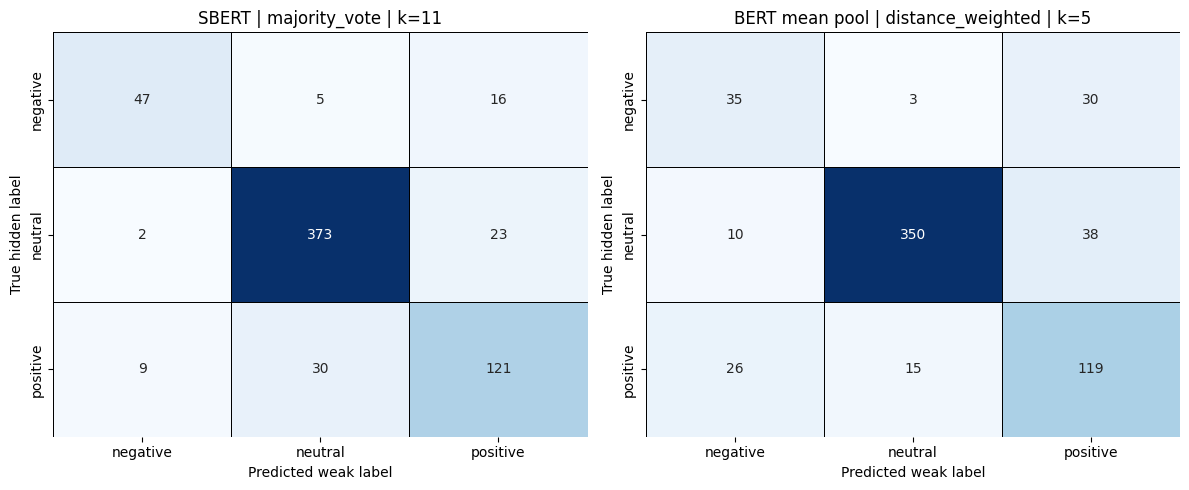

In [45]:
best_setting_rows = [best_sbert_row, best_bert_row]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, best_row in zip(axes, best_setting_rows):
    setting_key = (
        f"{best_row['embedding_name']} | {best_row['vote_mode']} | k={int(best_row['k'])}"
    )
    confusion = weak_label_confusion_matrices[setting_key]
    label_order = confusion["label_order"]
    label_names = [SENTIMENT_ID2LABEL[label_id] for label_id in label_order]

    confusion_df = pd.DataFrame(
        confusion["matrix"],
        index=label_names,
        columns=label_names,
    )

    sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    ax=ax,
)

    ax.set_title(
        f"{best_row['embedding_name']} | {best_row['vote_mode']} | k={int(best_row['k'])}"
    )
    ax.set_xlabel("Predicted weak label")
    ax.set_ylabel("True hidden label")

plt.tight_layout()
plt.show()

#### Result Discussion

The direct weak-label results show a clear advantage for **SBERT** over **BERT mean pooling**. Across all tested settings, the SBERT-based weak labels are consistently stronger, especially on the main target metric **negative F1**. The best overall configuration is **SBERT + majority vote + \(k=11\)**, which reaches an accuracy of **0.864**, a macro-F1 of **0.809**, and a negative F1 of **0.746**. By contrast, the best BERT-based setup—**distance-weighted vote with \(k=5\)**—achieves a clearly lower negative F1 of **0.504**.

This confirms the impression from the embedding diagnostics: SBERT provides a more useful representation for semantic nearest-neighbor labeling. The performance gap is especially visible on the negative class, where the best SBERT setup combines both high precision (**0.810**) and solid recall (**0.691**), while the best BERT setup remains noticeably weaker on both dimensions.

The comparison of voting rules is also informative. For **BERT mean pooling**, **distance weighting** helps slightly and produces the best BERT result. For **SBERT**, however, the strongest configuration is actually **majority vote** with a larger neighborhood size. This suggests that once the embedding space is good enough, a broader and simpler neighborhood vote can be more robust than emphasizing only the closest neighbors.

The confusion matrices support the same conclusion. The best **SBERT** setup makes fewer severe errors overall and preserves the negative class much better than the best **BERT** setup. In particular, BERT more often confuses **negative** examples with **positive**, whereas SBERT keeps this confusion substantially lower. Since the weak labels are later added to the original 1000 seed examples, this result provides a strong basis for the semi-supervised step: the selected SBERT configuration produces weak labels that are accurate enough to justify downstream retraining on the combined dataset of **1626 examples**.

### 4.5 Qualitative Error Analysis of the Best SBERT Weak Labels

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.15.22.png" alt="" width="60%">
</div>


Using SBERT | majority_vote | k=11, the examples below show a few representative mistakes on `hidden_allagree_pool`.

In [47]:
qualitative_sbert_setting_key = (
    f"{best_sbert_row['embedding_name']} | "
    f"{best_sbert_row['vote_mode']} | k={int(best_sbert_row['k'])}"
)
qualitative_sbert_errors_df = weak_label_predictions[
    qualitative_sbert_setting_key
]["weak_labeled_hidden_df"].copy()
qualitative_sbert_errors_df["true_label_name"] = qualitative_sbert_errors_df[
    "true_label"
].map(SENTIMENT_ID2LABEL)
qualitative_sbert_errors_df["predicted_label_name"] = qualitative_sbert_errors_df[
    "weak_label"
].map(SENTIMENT_ID2LABEL)

qualitative_error_cases = [
    ("negative", "positive"),
    ("positive", "negative"),
    ("neutral", "negative"),
    ("positive", "neutral"),
]

for true_label_name, predicted_label_name in qualitative_error_cases:
    case_examples_df = qualitative_sbert_errors_df[
        (qualitative_sbert_errors_df["true_label_name"] == true_label_name)
        & (
            qualitative_sbert_errors_df["predicted_label_name"]
            == predicted_label_name
        )
    ][
        [
            "sentence",
            "true_label_name",
            "predicted_label_name",
            "weak_label_confidence",
        ]
    ].sort_values("weak_label_confidence", ascending=False).head(3)

    display(
        Markdown(
            f"#### `{true_label_name}` predicted as `{predicted_label_name}`"
        )
    )

    if case_examples_df.empty:
        print("No examples found for this error type.")
    else:
        display(
            case_examples_df.rename(
                columns={"weak_label_confidence": "prediction_confidence"}
            ).style.format({"prediction_confidence": "{:.3f}"})
        )


#### `negative` predicted as `positive`

,sentence,true_label_name,predicted_label_name,prediction_confidence
example_id,,,,
allagree_00726,"Profitability ( EBIT % ) was 13.6 % , compared to 14.3 % in Q2 2009 .",negative,positive,0.909
allagree_02132,Finnish business software group AffectoGenimap Oyj said its net profit halved to 1.2 mln euro ( $ 1.5 mln ) in the first nine months of 2006 from 2.2 mln euro ( $ 2.8 mln ) in the same period of 2005 .,negative,positive,0.727
allagree_00793,"ADP News - Feb 13 , 2009 - Finnish retailer Kesko Oyj HEL : KESBV said today its total sales , excluding value added tax VAT , stood at EUR 661.3 million USD 853.1 m in January 2009 , down 15.2 % year-on-yea",negative,positive,0.727


#### `positive` predicted as `negative`

,sentence,true_label_name,predicted_label_name,prediction_confidence
example_id,,,,
allagree_00837,"Pre-tax loss totaled EUR 0.3 mn , compared to a loss of EUR 2.2 mn in the first quarter of 2005 .",positive,negative,1.000
allagree_00327,"`` The number of collection errors fell considerably , and operations speeded up .",positive,negative,0.909
allagree_00346,The loss for the third quarter of 2007 was EUR 0.3 mn smaller than the loss of the second quarter of 2007 .,positive,negative,0.727


#### `neutral` predicted as `negative`

,sentence,true_label_name,predicted_label_name,prediction_confidence
example_id,,,,
allagree_02062,"Typically , the transmission power level can be decreased when the interference noise is above a predefined value .",neutral,negative,0.545
allagree_00939,"CapMan said the deal 's effect on its cash flow for 2009 totals EUR3 .4 m , but the transaction would not affect its financial results for 2009 as it was executed at fair value .",neutral,negative,0.364


#### `positive` predicted as `neutral`

,sentence,true_label_name,predicted_label_name,prediction_confidence
example_id,,,,
allagree_00781,"Investors will continue being interested in the company 's share although it is not quite cheap , Affarsvarlden said .",positive,neutral,0.909
allagree_00253,"The disposal of Autotank will also strengthen Aspo 's capital structure , '' commented Gustav Nyberg , CEO of Aspo .",positive,neutral,0.909
allagree_00034,"Shares of Standard Chartered ( STAN ) rose 1.2 % in the FTSE 100 , while Royal Bank of Scotland ( RBS ) shares rose 2 % and Barclays shares ( BARC ) ( BCS ) were up 1.7 % .",positive,neutral,0.909


#### Result Discussion

The qualitative error analysis helps explain why weak labeling remains imperfect even in the best SBERT-based setup. Several errors occur in sentences whose sentiment depends on **financial interpretation rather than explicit sentiment words**. For example, statements about falling profits, declining sales, or smaller losses can easily be mapped to the wrong class because they combine positive and negative signals in the same sentence.

A clear pattern is that many mistakes happen near the boundary between **negative** and **positive**, or between **positive** and **neutral**. This is consistent with the confusion matrices and reflects the fact that financial sentiment is often subtle: a sentence can describe an improvement in a still-negative situation, or a decline that is stated in a neutral, factual tone. In such cases, nearest-neighbor weak labeling may transfer the sentiment of semantically similar wording without fully capturing the financial direction of the statement.

The examples also show that some incorrect weak labels are assigned with fairly high confidence. This is an important reminder that confidence in embedding-space voting is not the same as semantic correctness. Overall, the qualitative analysis supports the earlier quantitative findings: the weak labels are useful and often plausible, but they still struggle with **borderline financial statements** and with cases where sentiment depends on a fine-grained interpretation of change, comparison, or business context.

## 5. Semi-Supervised Training

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.15.40.png" alt="" width="60%">
</div>


### 5.1 Setup

After identifying a suitable weak-labeling configuration, the notebook moves to the central question of whether these weak labels can actually improve the downstream sentiment classifier. We start with a clean hard-labeled seed set, generate additional weak labels for the fixed `hidden_allagree_pool`, and then retrain the classifier on the **combined hard + weak-labeled dataset**.

To keep this stage methodologically clean, we first perform a **small learning-rate tuning step** on `val_allagree` and selects the best one based on **negative F1**. The goal is not to maximize benchmark performance at all costs, but to avoid carrying a clearly suboptimal learning rate into the semi-supervised experiments.

This section asks the key question of the notebook: **can weak labels generated from a small number of reliable annotations reduce manual labeling effort without sacrificing classifier quality?**

In [48]:
semisup_backbone_selection_size = max(train_sizes)

semisup_backbone_candidates_df = baseline_results_df[
    (baseline_results_df["evaluation_split"] == "val_allagree")
    & (baseline_results_df["train_size"] == semisup_backbone_selection_size)
].copy()

# Choose one backbone once, then keep it fixed for the later semi-supervised runs.
selected_backbone_row = (
    semisup_backbone_candidates_df
    .sort_values(
        ["negative_f1", "macro_f1", "model_key"],
        ascending=[False, False, True],
    )
    .iloc[0]
)
selected_backbone_key = selected_backbone_row["model_key"]
selected_backbone_name = selected_backbone_row["model_name"]
selected_backbone_epochs = selected_epochs_by_model_key[selected_backbone_key]

selected_backbone_summary = selected_backbone_row.to_dict()
selected_backbone_summary["selected_epochs"] = selected_backbone_epochs
selected_backbone_df = pd.DataFrame([selected_backbone_summary])

print("Selected backbone key:", selected_backbone_key)
print("Selected backbone model:", selected_backbone_name)
print("Selected backbone epochs:", selected_backbone_epochs)


Selected backbone key: modernbert
Selected backbone model: answerdotai/ModernBERT-base
Selected backbone epochs: 7


In [27]:
LEARNING_RATE_CANDIDATES = [2e-5, 3e-5, 5e-5]
LEARNING_RATE_TUNING_SIZE = max(train_sizes)
learning_rate_tuning_results = []

lr_tuning_train_df = splits[f"train_{LEARNING_RATE_TUNING_SIZE}"][["sentence", "label"]].copy()

# Small sweep only: just enough to avoid depending on one default learning rate.
for candidate_learning_rate in LEARNING_RATE_CANDIDATES:
    print(
        f"Testing learning_rate={candidate_learning_rate:.0e} "
        f"for {selected_backbone_key} on train_{LEARNING_RATE_TUNING_SIZE} "
        f"with {selected_backbone_epochs} epochs"
    )

    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(lr_tuning_train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=(
                f"models/lr_tuning_{selected_backbone_key}_"
                f"{str(candidate_learning_rate).replace('.', '_')}"
            ),
            batch_size=16,
            epochs=selected_backbone_epochs,
            learning_rate=candidate_learning_rate,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    val_predictions = trainer.predict(val_dataset)
    val_metrics = compute_metrics(
        (val_predictions.predictions, val_predictions.label_ids),
        negative_label=NEGATIVE_LABEL,
    )

    learning_rate_tuning_results.append(
        {
            "backbone_key": selected_backbone_key,
            "backbone_name": selected_backbone_name,
            "epochs": selected_backbone_epochs,
            "train_size": LEARNING_RATE_TUNING_SIZE,
            "learning_rate": candidate_learning_rate,
            **val_metrics,
        }
    )

learning_rate_tuning_df = pd.DataFrame(learning_rate_tuning_results).sort_values(
    ["negative_f1", "macro_f1", "accuracy", "learning_rate"],
    ascending=[False, False, False, True],
).reset_index(drop=True)
selected_learning_rate = float(learning_rate_tuning_df.iloc[0]["learning_rate"])

display(
    learning_rate_tuning_df.style.format(
        {
            "learning_rate": "{:.0e}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"])
)

print("Selected learning rate:", f"{selected_learning_rate:.0e}")


Testing learning_rate=2e-05 for modernbert on train_1000 with 7 epochs


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '94.52', 'train_samples_per_second': '74.06', 'train_steps_per_second': '4.666', 'train_loss': '0.1168', 'epoch': '7'}
Testing learning_rate=3e-05 for modernbert on train_1000 with 7 epochs


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '93.2', 'train_samples_per_second': '75.11', 'train_steps_per_second': '4.732', 'train_loss': '0.123', 'epoch': '7'}
Testing learning_rate=5e-05 for modernbert on train_1000 with 7 epochs


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '92.54', 'train_samples_per_second': '75.64', 'train_steps_per_second': '4.765', 'train_loss': '0.1191', 'epoch': '7'}


,backbone_key,backbone_name,epochs,train_size,learning_rate,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,modernbert,answerdotai/ModernBERT-base,7,1000,2e-05,0.9669,0.9584,0.9231,1.0000,0.9600
1,modernbert,answerdotai/ModernBERT-base,7,1000,5e-05,0.9669,0.9580,0.9231,1.0000,0.9600
2,modernbert,answerdotai/ModernBERT-base,7,1000,3e-05,0.9613,0.9530,0.9231,1.0000,0.9600


Selected learning rate: 2e-05


### 5.2 Training

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.15.58.png" alt="" width="60%">
</div>


The semi-supervised comparison is structured as a direct contrast between:

- a **hard-label baseline**, trained only on the clean labeled seed data
- a **semi-supervised model**, trained on the same hard labels plus the selected weak labels

This comparison is repeated across the nested training sizes **100, 250, 500, and 1000**, while keeping the hidden pool fixed. Like this we can test not only whether weak labels help, but also **when** they help most. In particular, the expectation is that weak labeling should be most beneficial in the **low-label regime**, where the supervised model has the least amount of human-labeled data available.

As in the earlier sections, evaluation is performed on both **`test_allagree`** and **`test_disagree`**. This makes it possible to distinguish between improvements on clean high-agreement examples and performance on more ambiguous lower-agreement cases.

In [28]:
semisup_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

if best_embedding_name == "SBERT":
    semisup_seed_embeddings_by_size = sbert_train_embeddings_by_size
    semisup_hidden_embeddings = sbert_hidden_embeddings
elif best_embedding_name == "BERT mean pool":
    semisup_seed_embeddings_by_size = bert_train_embeddings_by_size
    semisup_hidden_embeddings = bert_hidden_embeddings
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")


def train_and_evaluate_semisup_run(
    run_name,
    train_df,
    seed_size,
    output_dir,
    learning_rate=selected_learning_rate,
    epochs=None,
):
    """Train one run and evaluate it on the fixed validation and test splits."""
    if epochs is None:
        epochs = selected_backbone_epochs

    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=output_dir,
            batch_size=16,
            epochs=epochs,
            learning_rate=learning_rate,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    run_results = []
    for evaluation_split_name, evaluation_split_df in semisup_eval_splits.items():
        evaluation_dataset = prepare_text_dataset(
            evaluation_split_df,
            classifier.tokenizer,
        )
        evaluation_predictions = trainer.predict(evaluation_dataset)
        evaluation_metrics = compute_metrics(
            (evaluation_predictions.predictions, evaluation_predictions.label_ids),
            negative_label=NEGATIVE_LABEL,
        )

        run_results.append(
            {
                "run_type": run_name,
                "backbone_key": selected_backbone_key,
                "backbone_name": selected_backbone_name,
                "epochs": epochs,
                "learning_rate": learning_rate,
                "train_size": seed_size,
                "evaluation_split": evaluation_split_name,
                **evaluation_metrics,
            }
        )

    return run_results


In [29]:
semisup_results = []
semisup_results_by_size = {}

for semisup_train_size in train_sizes:
    print()
    print(f"=== Semi-supervised comparison for train_{semisup_train_size} ===")

    current_seed_df = splits[f"train_{semisup_train_size}"][["sentence", "label"]].copy()
    current_seed_labels = train_labels_by_size[semisup_train_size]
    current_seed_embeddings = semisup_seed_embeddings_by_size[semisup_train_size]

    # Regenerate weak labels for each seed size, but keep the hidden pool itself fixed.
    (
        current_weak_labels,
        current_neighbor_indices,
        current_neighbor_distances,
        current_confidence_scores,
    ) = predict_knn_labels(
        train_embeddings=current_seed_embeddings,
        train_labels=current_seed_labels,
        query_embeddings=semisup_hidden_embeddings,
        k=best_k,
        vote_mode=best_vote_mode,
    )

    current_weak_hidden_df = hidden_allagree_pool.copy()
    current_weak_hidden_df["true_label"] = hidden_allagree_pool["label"].to_numpy()
    current_weak_hidden_df["label"] = current_weak_labels
    current_weak_hidden_df["weak_label"] = current_weak_labels
    current_weak_hidden_df["weak_label_confidence"] = current_confidence_scores
    current_weak_hidden_df["embedding_name"] = best_embedding_name
    current_weak_hidden_df["vote_mode"] = best_vote_mode
    current_weak_hidden_df["k"] = best_k
    current_weak_hidden_df["is_weak"] = True

    current_combined_train_df = pd.concat(
        [
            current_seed_df,
            current_weak_hidden_df[["sentence", "label"]],
        ],
        ignore_index=True,
    )

    current_baseline_results = train_and_evaluate_semisup_run(
        run_name="baseline_hard_only",
        train_df=current_seed_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_baseline_{selected_backbone_key}_{semisup_train_size}"
        ),
    )
    current_semisup_results = train_and_evaluate_semisup_run(
        run_name="semi_supervised_hard_plus_weak",
        train_df=current_combined_train_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_weak_{selected_backbone_key}_{semisup_train_size}"
        ),
    )

    semisup_results.extend(current_baseline_results)
    semisup_results.extend(current_semisup_results)
    semisup_results_by_size[semisup_train_size] = {
        "baseline_results": current_baseline_results,
        "semisup_results": current_semisup_results,
        "weak_labels": current_weak_labels,
        "weak_label_confidence": current_confidence_scores,
        "weak_hidden_df": current_weak_hidden_df,
        "combined_train_df": current_combined_train_df,
    }



=== Semi-supervised comparison for train_100 ===


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '8.64', 'train_samples_per_second': '81.02', 'train_steps_per_second': '5.671', 'train_loss': '0.3486', 'epoch': '7'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '68.55', 'train_samples_per_second': '74.14', 'train_steps_per_second': '4.698', 'train_loss': '0.1916', 'epoch': '7'}

=== Semi-supervised comparison for train_250 ===


...

{'train_runtime': '102.8', 'train_samples_per_second': '76.64', 'train_steps_per_second': '4.833', 'train_loss': '0.1513', 'epoch': '7'}

=== Semi-supervised comparison for train_1000 ===


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '87.62', 'train_samples_per_second': '79.89', 'train_steps_per_second': '5.033', 'train_loss': '0.1156', 'epoch': '7'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '141.9', 'train_samples_per_second': '80.22', 'train_steps_per_second': '5.032', 'train_loss': '0.1212', 'epoch': '7'}


#### Compare hard-label baseline and semi-supervised runs

In [30]:
semisup_learning_curve_df = pd.DataFrame(semisup_results)
semisup_learning_curve_df = semisup_learning_curve_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "learning_rate",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(
    ["evaluation_split", "train_size", "run_type"],
    ascending=[True, True, True],
).reset_index(drop=True)

semisup_comparison_df = semisup_learning_curve_df.copy()
semisup_baseline_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "baseline_hard_only"
].to_dict("records")
semisup_weak_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "semi_supervised_hard_plus_weak"
].to_dict("records")

semisup_metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
]

display(
    semisup_learning_curve_df.style.format(
        {
            "learning_rate": "{:.0e}",
            **{column: "{:.4f}" for column in semisup_metric_columns},
        }
    ).background_gradient(
        subset=["negative_f1"],
    )
)


,run_type,backbone_key,backbone_name,learning_rate,train_size,evaluation_split,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_allagree,0.7367,0.6269,0.3667,0.5410,0.4371
1,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_allagree,0.7743,0.7292,0.5957,0.9180,0.7226
2,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,250,test_allagree,0.8916,0.8588,0.7910,0.8689,0.8281
3,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,2e-05,250,test_allagree,0.8407,0.8230,0.7692,0.9836,0.8633
4,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,500,test_allagree,0.9535,0.9401,0.9492,0.9180,0.9333
5,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,2e-05,500,test_allagree,0.9071,0.8752,0.8644,0.8361,0.8500
6,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,1000,test_allagree,0.9801,0.9781,0.9683,1.0000,0.9839
7,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,2e-05,1000,test_allagree,0.9425,0.9210,0.9298,0.8689,0.8983
8,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_disagree,0.5795,0.3911,0.2368,0.1500,0.1837
9,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_disagree,0.6008,0.5295,0.5283,0.4667,0.4956


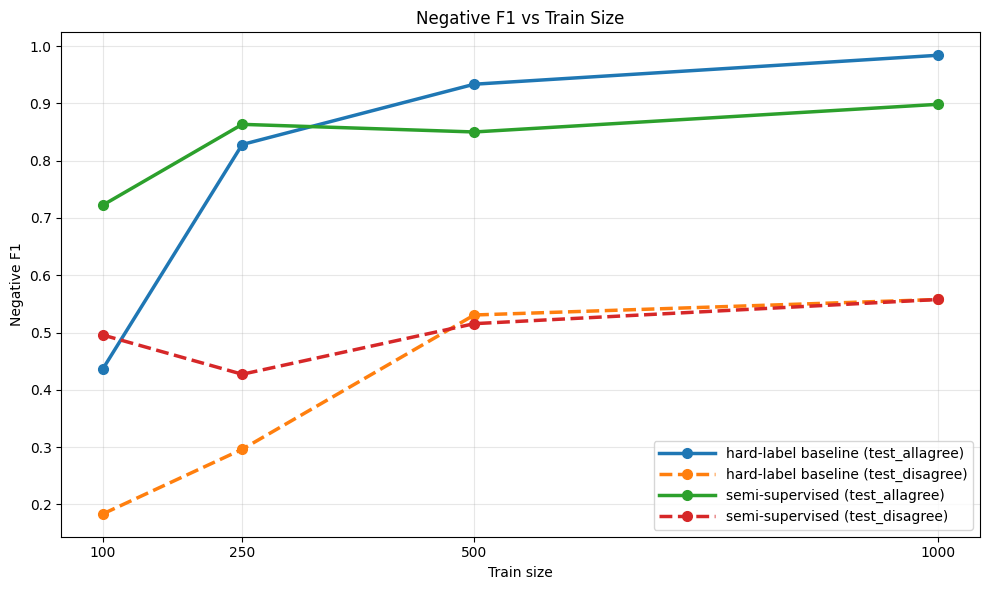

In [50]:
plot_df = semisup_learning_curve_df[
    semisup_learning_curve_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()

run_label_map = {
    "baseline_hard_only": "hard-label baseline",
    "semi_supervised_hard_plus_weak": "semi-supervised",
}

split_styles = {
    "test_allagree": "-",
    "test_disagree": "--",
}

plt.figure(figsize=(10, 6))

for run_type in ["baseline_hard_only", "semi_supervised_hard_plus_weak"]:
    for split_name in ["test_allagree", "test_disagree"]:
        run_df = plot_df[
            (plot_df["run_type"] == run_type) &
            (plot_df["evaluation_split"] == split_name)
        ].sort_values("train_size")

        plt.plot(
            run_df["train_size"],
            run_df["negative_f1"],
            marker="o",
            linestyle=split_styles[split_name],
            linewidth=2.5,
            markersize=7,
            label=f"{run_label_map[run_type]} ({split_name})",
        )

plt.title("Negative F1 vs Train Size")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(train_sizes)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", frameon=True, handlelength=4)
plt.tight_layout()
plt.show()

#### Result Discussion

The semi-supervised results show a clear and consistent pattern: **weak labeling is most helpful in the low-label regime**. At `train_100`, the gain is substantial on both evaluation splits. On `test_allagree`, negative F1 improves from **0.437** to **0.723**, and on `test_disagree` it rises from **0.184** to **0.496**. This suggests that when only very few hard labels are available, the additional weak labels provide a strong signal that the classifier can exploit.

A positive effect is still visible at `train_250`. On `test_allagree`, the semi-supervised model slightly outperforms the hard-label baseline (**0.863** vs. **0.828**), and on `test_disagree` it also improves clearly (**0.427** vs. **0.296**). This indicates that the benefit of weak labeling does not disappear immediately after the very smallest training size, but it is already smaller than at `train_100`.

From `train_500` onward, however, the picture changes. On `test_allagree`, the hard-label baseline becomes stronger than the semi-supervised variant, and the same is broadly true on `val_allagree`. This suggests that once the model already has enough clean manual labels, the additional weak labels no longer help and may even introduce enough noise to slightly reduce clean-test performance. On `test_disagree`, the differences are much smaller: at `train_500` the baseline remains slightly better, while at `train_1000` both approaches reach essentially the same negative F1.

Overall, the learning curves support the main practical conclusion of the notebook: **semi-supervised learning is most useful when manual labels are scarce**. The selected weak-labeling setup can substantially improve negative-class performance at small training sizes, but its advantage decreases as the amount of clean labeled data grows. This is exactly the pattern one would expect from a useful weak-labeling pipeline: it helps most when the supervised baseline is still data-limited, and it becomes less important once the classifier is already trained on a sufficiently large and reliable labeled set.

### 5.3 Time-Savings Estimate

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.16.21.png" alt="" width="60%">
</div>


After comparing the hard-label baseline with the semi-supervised variant, the next step is to translate the performance differences into a more practical quantity: **estimated manual labeling savings**. The key idea is simple: if a semi-supervised model trained on a smaller hard-label seed set reaches the same performance as a purely supervised model trained on a larger labeled set, then the difference between those two label counts can be interpreted as saved annotation effort.

The time-savings estimate is based on the **negative F1 learning curves**, because negative F1 is the main target metric throughout the analysis. The reference split is **`test_allagree`**, since it provides the cleanest estimate of how much supervised signal would otherwise be needed to reach a given level of performance. A secondary view on **`test_disagree`** is also included for completeness.

To make the estimate more realistic, the notebook does not rely only on exact matches between the observed baseline and semi-supervised train sizes. Instead, it uses a simple **linear interpolation** on the baseline curve to estimate how many hard-labeled examples the baseline would need in order to reach the same negative F1 as a given semi-supervised point. This avoids the overly rigid “no match” problem that would arise if only the four observed training sizes were considered.

The result should be interpreted as a **proxy for annotation savings**, not as an exact economic measure, as e.g. the additional cost for creating the weak labels are not considered.

In [32]:
time_savings_eval_splits = ["test_allagree", "test_disagree"]

baseline_curve_for_savings_df = semisup_learning_curve_df[
    (semisup_learning_curve_df["run_type"] == "baseline_hard_only")
    & (semisup_learning_curve_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()

semisup_curve_for_savings_df = semisup_learning_curve_df[
    (semisup_learning_curve_df["run_type"] == "semi_supervised_hard_plus_weak")
    & (semisup_learning_curve_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()


def interpolate_baseline_labels_needed(baseline_split_df, target_negative_f1):
    """Map a semi-supervised score back onto the hard-label baseline curve."""
    baseline_split_df = baseline_split_df.sort_values("train_size").reset_index(drop=True)
    x_values = baseline_split_df["train_size"].to_numpy(dtype=float)
    y_values = baseline_split_df["negative_f1"].to_numpy(dtype=float)

    if target_negative_f1 < y_values.min():
        return np.nan, "below observed baseline range"
    if target_negative_f1 > y_values.max():
        return np.nan, "above observed baseline range"

    exact_matches = baseline_split_df[
        np.isclose(baseline_split_df["negative_f1"], target_negative_f1, atol=1e-10)
    ]
    if not exact_matches.empty:
        return float(exact_matches["train_size"].min()), "exact observed baseline point"

    candidate_estimates = []
    for idx in range(len(baseline_split_df) - 1):
        x1, x2 = x_values[idx], x_values[idx + 1]
        y1, y2 = y_values[idx], y_values[idx + 1]
        lower_y, upper_y = sorted([y1, y2])

        if lower_y <= target_negative_f1 <= upper_y:
            if np.isclose(y1, y2):
                candidate_estimates.append(x1)
            else:
                fraction = (target_negative_f1 - y1) / (y2 - y1)
                candidate_estimates.append(x1 + fraction * (x2 - x1))

    if not candidate_estimates:
        return np.nan, "within range but no crossing segment found"

    return float(min(candidate_estimates)), "linearly interpolated between baseline points"


time_savings_rows = []

for evaluation_split_name in time_savings_eval_splits:
    baseline_split_df = baseline_curve_for_savings_df[
        baseline_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")
    semisup_split_df = semisup_curve_for_savings_df[
        semisup_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")

    for _, semisup_row in semisup_split_df.iterrows():
        target_negative_f1 = float(semisup_row["negative_f1"])
        (
            interpolated_baseline_labels_needed,
            interpolation_status,
        ) = interpolate_baseline_labels_needed(
            baseline_split_df,
            target_negative_f1,
        )

        if pd.isna(interpolated_baseline_labels_needed):
            absolute_labels_saved = np.nan
            relative_labels_saved_pct = np.nan
        else:
            absolute_labels_saved = (
                interpolated_baseline_labels_needed
                - float(semisup_row["train_size"])
            )
            relative_labels_saved_pct = (
                100 * absolute_labels_saved / interpolated_baseline_labels_needed
            )

        time_savings_rows.append(
            {
                "eval_split": evaluation_split_name,
                "semi_supervised_train_size": int(semisup_row["train_size"]),
                "semi_supervised_negative_f1": target_negative_f1,
                "interpolated_baseline_labels_needed": interpolated_baseline_labels_needed,
                "absolute_labels_saved": absolute_labels_saved,
                "relative_labels_saved_pct": relative_labels_saved_pct,
                "interpolation_status": interpolation_status,
            }
        )

time_savings_df = pd.DataFrame(time_savings_rows)
primary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_allagree"
].reset_index(drop=True)
secondary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_disagree"
].reset_index(drop=True)

display(
    time_savings_df.style.format(
        {
            "semi_supervised_negative_f1": "{:.4f}",
            "interpolated_baseline_labels_needed": "{:.1f}",
            "absolute_labels_saved": "{:.1f}",
            "relative_labels_saved_pct": "{:.1f}",
        },
        na_rep="not estimated",
    ).background_gradient(
        subset=["absolute_labels_saved"],
    )
)


,eval_split,semi_supervised_train_size,semi_supervised_negative_f1,interpolated_baseline_labels_needed,absolute_labels_saved,relative_labels_saved_pct,interpolation_status
0,test_allagree,100,0.7226,209.5,109.5,52.3,linearly interpolated between baseline points
1,test_allagree,250,0.8633,333.6,83.6,25.1,linearly interpolated between baseline points
2,test_allagree,500,0.8500,302.0,-198.0,-65.6,linearly interpolated between baseline points
3,test_allagree,1000,0.8983,416.8,-583.2,-139.9,linearly interpolated between baseline points
4,test_disagree,100,0.4956,462.6,362.6,78.4,linearly interpolated between baseline points
5,test_disagree,250,0.4272,389.6,139.6,35.8,linearly interpolated between baseline points
6,test_disagree,500,0.5155,483.8,-16.2,-3.3,linearly interpolated between baseline points
7,test_disagree,1000,0.5577,1000.0,0.0,0.0,exact observed baseline point


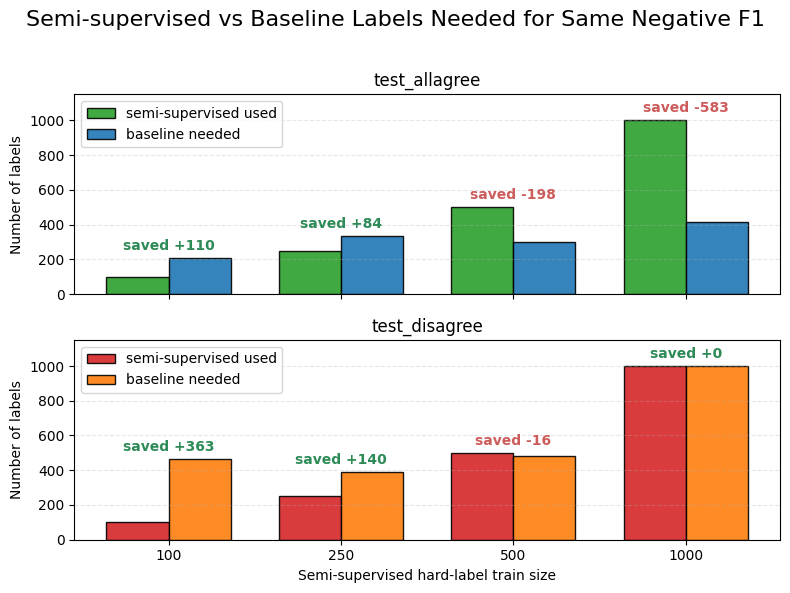

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

plot_configs = [
    (
        primary_time_savings_df.copy().sort_values("semi_supervised_train_size"),
        axes[0],
        "test_allagree",
        "tab:green",   # semi-supervised
        "tab:blue",    # baseline
    ),
    (
        secondary_time_savings_df.copy().sort_values("semi_supervised_train_size"),
        axes[1],
        "test_disagree",
        "tab:red",     # semi-supervised
        "tab:orange",  # baseline
    ),
]

width = 0.36

for df, ax, split_name, semi_color, baseline_color in plot_configs:
    x = np.arange(len(df))

    semi = df["semi_supervised_train_size"].to_numpy()
    baseline_needed = df["interpolated_baseline_labels_needed"].to_numpy()
    saved = df["absolute_labels_saved"].to_numpy()

    ax.bar(
        x - width / 2,
        semi,
        width,
        color=semi_color,
        edgecolor="black",
        alpha=0.9,
        label="semi-supervised used",
    )

    ax.bar(
        x + width / 2,
        baseline_needed,
        width,
        color=baseline_color,
        edgecolor="black",
        alpha=0.9,
        label="baseline needed",
    )

    y_max = max(np.nanmax(semi), np.nanmax(baseline_needed))
    ax.set_ylim(0, y_max * 1.15)

    for i, val in enumerate(saved):
        text_color = "seagreen" if val >= 0 else "indianred"
        y_text = max(semi[i], baseline_needed[i]) + y_max * 0.03

        ax.text(
            x[i],
            y_text,
            f"saved {val:+.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=text_color,
        )

    ax.set_title(split_name)
    ax.set_ylabel("Number of labels")
    ax.set_xticks(x)
    ax.set_xticklabels(df["semi_supervised_train_size"].astype(str))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(loc="upper left", frameon=True)

axes[1].set_xlabel("Semi-supervised hard-label train size")

fig.suptitle("Semi-supervised vs Baseline Labels Needed for Same Negative F1", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Result Discussion

The time-savings estimate confirms the main pattern already seen in the semi-supervised learning curves: **weak labeling is most valuable when only a small number of manual labels is available**. On `test_allagree`, the semi-supervised model trained with **100 hard labels** reaches a negative F1 that would require about **210 hard labels** in the purely supervised baseline, corresponding to a saving of roughly **110 labels** (**52%**). A positive effect is still visible at **250 labels**, although it is smaller.

The effect is even stronger on `test_disagree` in the low-label regime. At **100 hard labels**, the semi-supervised setup reaches a performance level that the baseline would only achieve with about **463 labels**, which corresponds to a saving of roughly **363 labels** (**78%**). At **250 labels**, the estimated saving is still substantial.

At larger training sizes, however, the interpretation changes. For **500** and especially **1000** hard labels on `test_allagree`, the semi-supervised model no longer improves over the baseline, so the estimated label savings become negative. This does not mean that weak labeling is harmful in general, but rather that in this regime the supervised baseline is already strong enough that the added weak labels no longer provide a net benefit. A similar pattern appears on `test_disagree`, where the advantage becomes very small at **500 labels** and disappears completely at **1000 labels**.

### 5.4 Agreement-Level Seed Comparison

The previous semi-supervised results showed how much weak labeling can help when the seed labels come from the clean **100% agreement** subset. The next question is whether this benefit depends on the **quality of the seed labels themselves**. 

To answer this, we compare two seed conditions:

- **high-agreement seeds**, taken from the 100%-agreement training data
- **lower-agreement seeds**, sampled from the combined non-100%-agreement pool

The comparison is kept as fair as possible. For each train size, the two seed sets are matched in size, the same hidden target pool is used for weak labeling, and the same selected weak-labeling configuration and classifier backbone are reused. This makes it possible to isolate the effect of **seed-label quality** rather than changing several parts of the pipeline at once.

The analysis is performed at two levels. First, we compare the **direct quality of the generated weak labels**. Second, we compare the **downstream semi-supervised classifier performance** after retraining on those weak labels. In this way, the section can show not only whether high-agreement seeds produce cleaner weak labels, but also whether that advantage actually matters for the final classifier.

The goal of this subsection is therefore to answer a practical question: **if manual labels are limited, is it more valuable to have more labels, or to have cleaner labels?**

In [34]:
agreement_high_seed_dfs_by_size = {
    train_size: splits[f"train_{train_size}"][["sentence", "label"]].copy()
    for train_size in train_sizes
}
agreement_lower_seed_dfs_by_size = {}
agreement_seed_overview_rows = []

for train_size in train_sizes:
    # Match the lower-agreement seed size so the comparison isolates label quality.
    lower_seed_df, _ = train_test_split(
        splits["combined_non100_pool"][["sentence", "label"]].copy(),
        train_size=train_size,
        random_state=42 + train_size,
        stratify=splits["combined_non100_pool"]["label"],
    )
    lower_seed_df = lower_seed_df.reset_index(drop=True)
    agreement_lower_seed_dfs_by_size[train_size] = lower_seed_df

    for seed_condition, seed_df in {
        "high_agreement_seed": agreement_high_seed_dfs_by_size[train_size],
        "lower_agreement_seed": lower_seed_df,
    }.items():
        label_counts = seed_df["label"].value_counts().sort_index()
        agreement_seed_overview_rows.append(
            {
                "train_size": train_size,
                "seed_condition": seed_condition,
                **{
                    f"{label_name}_count": int(label_counts.get(label_id, 0))
                    for label_id, label_name in SENTIMENT_ID2LABEL.items()
                },
            }
        )

agreement_hidden_df = hidden_allagree_pool.copy()
agreement_hidden_true_labels = agreement_hidden_df["label"].to_numpy()

# Keep the hidden_allagree_pool fixed here too, so only the seed quality changes.
if best_embedding_name == "SBERT":
    agreement_hidden_embeddings = sbert_hidden_embeddings
    agreement_high_seed_embeddings_by_size = sbert_train_embeddings_by_size
    agreement_lower_seed_embeddings_by_size = {
        train_size: sbert_model.encode(
            agreement_lower_seed_dfs_by_size[train_size]["sentence"].tolist(),
            batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=SHOW_PROGRESS_BARS,
        )
        for train_size in train_sizes
    }
elif best_embedding_name == "BERT mean pool":
    agreement_hidden_embeddings = bert_hidden_embeddings
    agreement_high_seed_embeddings_by_size = bert_train_embeddings_by_size
    agreement_lower_seed_embeddings_by_size = {
        train_size: encode_with_plain_bert(
            agreement_lower_seed_dfs_by_size[train_size]["sentence"].tolist()
        )
        for train_size in train_sizes
    }
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")

agreement_seed_overview_df = pd.DataFrame(agreement_seed_overview_rows).sort_values(
    ["train_size", "seed_condition"]
).reset_index(drop=True)
display(agreement_seed_overview_df)


,train_size,seed_condition,negative_count,neutral_count,positive_count
0,100,high_agreement_seed,17,60,23
1,100,lower_agreement_seed,12,57,31
2,250,high_agreement_seed,34,142,74
3,250,lower_agreement_seed,29,144,77
4,500,high_agreement_seed,68,296,136
5,500,lower_agreement_seed,58,288,154
6,1000,high_agreement_seed,150,600,250
7,1000,lower_agreement_seed,117,576,307


The next table compares weak-label quality for high-agreement seeds and lower-agreement seeds at each train size.

In [35]:
agreement_weak_label_results = []
agreement_weak_label_outputs = {}

for train_size in train_sizes:
    agreement_seed_conditions = {
        "high_agreement_seed": {
            "seed_df": agreement_high_seed_dfs_by_size[train_size],
            "seed_labels": agreement_high_seed_dfs_by_size[train_size]["label"].to_numpy(),
            "seed_embeddings": agreement_high_seed_embeddings_by_size[train_size],
        },
        "lower_agreement_seed": {
            "seed_df": agreement_lower_seed_dfs_by_size[train_size],
            "seed_labels": agreement_lower_seed_dfs_by_size[train_size]["label"].to_numpy(),
            "seed_embeddings": agreement_lower_seed_embeddings_by_size[train_size],
        },
    }

    # Reuse the same best embedding family, vote mode, and k from the earlier section.
    for seed_condition, seed_values in agreement_seed_conditions.items():
        (
            predicted_labels,
            neighbor_indices,
            neighbor_distances,
            confidence_scores,
        ) = predict_knn_labels(
            train_embeddings=seed_values["seed_embeddings"],
            train_labels=seed_values["seed_labels"],
            query_embeddings=agreement_hidden_embeddings,
            k=best_k,
            vote_mode=best_vote_mode,
        )

        predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
        metrics = compute_metrics(
            (predicted_logits, agreement_hidden_true_labels),
            negative_label=NEGATIVE_LABEL,
        )

        weak_hidden_df = agreement_hidden_df.copy()
        weak_hidden_df["true_label"] = agreement_hidden_true_labels
        weak_hidden_df["label"] = predicted_labels
        weak_hidden_df["weak_label"] = predicted_labels
        weak_hidden_df["weak_label_confidence"] = confidence_scores
        weak_hidden_df["train_size"] = train_size
        weak_hidden_df["seed_condition"] = seed_condition
        weak_hidden_df["embedding_name"] = best_embedding_name
        weak_hidden_df["vote_mode"] = best_vote_mode
        weak_hidden_df["k"] = best_k
        weak_hidden_df["is_weak"] = True

        agreement_weak_label_results.append(
            {
                "train_size": train_size,
                "seed_condition": seed_condition,
                "embedding_name": best_embedding_name,
                "vote_mode": best_vote_mode,
                "k": best_k,
                **metrics,
                "mean_vote_confidence": confidence_scores.mean(),
            }
        )
        agreement_weak_label_outputs[(train_size, seed_condition)] = {
            "predicted_labels": predicted_labels,
            "neighbor_indices": neighbor_indices,
            "neighbor_distances": neighbor_distances,
            "confidence_scores": confidence_scores,
            "weak_hidden_df": weak_hidden_df,
        }

agreement_weak_label_df = pd.DataFrame(agreement_weak_label_results)
agreement_weak_label_df = agreement_weak_label_df[
    [
        "train_size",
        "seed_condition",
        "embedding_name",
        "vote_mode",
        "k",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["train_size", "seed_condition"]).reset_index(drop=True)

display(
    agreement_weak_label_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
            "mean_vote_confidence": "{:.3f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
    )
)


,train_size,seed_condition,embedding_name,vote_mode,k,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
0,100,high_agreement_seed,SBERT,majority_vote,11,0.7636,0.7028,0.5510,0.7941,0.6506,0.673
1,100,lower_agreement_seed,SBERT,majority_vote,11,0.5895,0.4399,0.3704,0.4412,0.4027,0.559
2,250,high_agreement_seed,SBERT,majority_vote,11,0.8003,0.7375,0.5870,0.7941,0.6750,0.705
3,250,lower_agreement_seed,SBERT,majority_vote,11,0.6885,0.4979,0.5294,0.1324,0.2118,0.597
4,500,high_agreement_seed,SBERT,majority_vote,11,0.8371,0.7658,0.6923,0.6618,0.6767,0.765
5,500,lower_agreement_seed,SBERT,majority_vote,11,0.6709,0.5182,0.4490,0.6471,0.5301,0.646
6,1000,high_agreement_seed,SBERT,majority_vote,11,0.8642,0.8093,0.8103,0.6912,0.7460,0.789
7,1000,lower_agreement_seed,SBERT,majority_vote,11,0.7077,0.5973,0.4811,0.7500,0.5862,0.645


The table below shows the downstream comparison after retraining with the same backbone, learning rate, and weak-labeling setup.

In [36]:
agreement_downstream_results = []

for train_size in train_sizes:
    agreement_high_seed_df = agreement_high_seed_dfs_by_size[train_size]
    agreement_lower_seed_df = agreement_lower_seed_dfs_by_size[train_size]

    agreement_high_combined_train_df = pd.concat(
        [
            agreement_high_seed_df,
            agreement_weak_label_outputs[
                (train_size, "high_agreement_seed")
            ]["weak_hidden_df"][["sentence", "label"]],
        ],
        ignore_index=True,
    )
    agreement_lower_combined_train_df = pd.concat(
        [
            agreement_lower_seed_df,
            agreement_weak_label_outputs[
                (train_size, "lower_agreement_seed")
            ]["weak_hidden_df"][["sentence", "label"]],
        ],
        ignore_index=True,
    )

    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="baseline_high_agreement_hard_only",
            train_df=agreement_high_seed_df,
            seed_size=train_size,
            output_dir=(
                f"models/agreement_baseline_high_{selected_backbone_key}_{train_size}"
            ),
        )
    )
    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="semi_supervised_high_agreement_seed",
            train_df=agreement_high_combined_train_df,
            seed_size=train_size,
            output_dir=f"models/agreement_semisup_high_{selected_backbone_key}_{train_size}",
        )
    )
    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="semi_supervised_lower_agreement_seed",
            train_df=agreement_lower_combined_train_df,
            seed_size=train_size,
            output_dir=f"models/agreement_semisup_lower_{selected_backbone_key}_{train_size}",
        )
    )

agreement_downstream_df = pd.DataFrame(agreement_downstream_results)
agreement_downstream_df = agreement_downstream_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "learning_rate",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(["evaluation_split", "train_size", "run_type"]).reset_index(drop=True)

display(
    agreement_downstream_df.style.format(
        {
            "learning_rate": "{:.0e}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
    )
)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '8.149', 'train_samples_per_second': '85.9', 'train_steps_per_second': '6.013', 'train_loss': '0.29', 'epoch': '7'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '63.44', 'train_samples_per_second': '80.11', 'train_steps_per_second': '5.076', 'train_loss': '0.1899', 'epoch': '7'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '2843', 'train_samples_per_second': '4.004', 'train_steps_per_second': '0.251', 'train_loss': '0.1241', 'epoch': '7'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '1958', 'train_samples_per_second': '5.813', 'train_steps_per_second': '0.365', 'train_loss': '0.2293', 'epoch': '7'}


,run_type,backbone_key,backbone_name,learning_rate,train_size,evaluation_split,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_allagree,0.7611,0.6496,0.4382,0.6393,0.5200
1,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_allagree,0.7854,0.7468,0.6333,0.9344,0.7550
2,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,100,test_allagree,0.6726,0.5071,0.4507,0.5246,0.4848
3,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,250,test_allagree,0.8850,0.8458,0.7465,0.8689,0.8030
4,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,250,test_allagree,0.8341,0.8137,0.7500,0.9836,0.8511
5,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,250,test_allagree,0.7279,0.5150,0.8000,0.0656,0.1212
6,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,500,test_allagree,0.9469,0.9314,0.9180,0.9180,0.9180
7,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,500,test_allagree,0.8894,0.8550,0.8333,0.8197,0.8264
8,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,2e-05,500,test_allagree,0.7146,0.5749,0.5227,0.7541,0.6174
9,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,2e-05,1000,test_allagree,0.9801,0.9730,0.9672,0.9672,0.9672


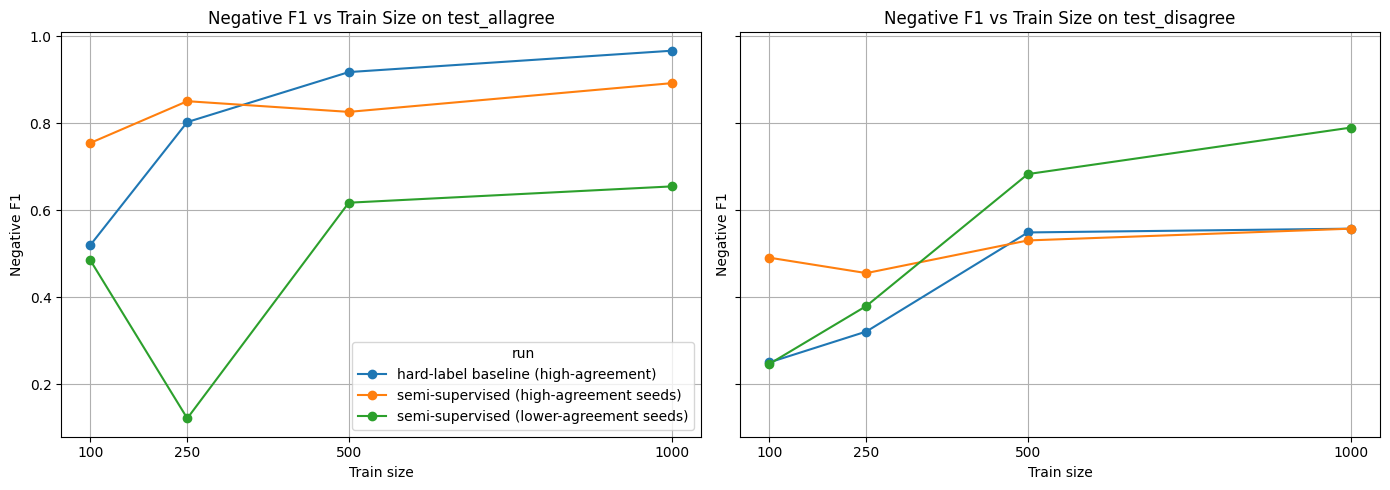

In [37]:
agreement_plot_df = agreement_downstream_df[
    agreement_downstream_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()
agreement_plot_df["run_label"] = agreement_plot_df["run_type"].map(
    {
        "baseline_high_agreement_hard_only": "hard-label baseline (high-agreement)",
        "semi_supervised_high_agreement_seed": "semi-supervised (high-agreement seeds)",
        "semi_supervised_lower_agreement_seed": "semi-supervised (lower-agreement seeds)",
    }
)
run_order = [
    "hard-label baseline (high-agreement)",
    "semi-supervised (high-agreement seeds)",
    "semi-supervised (lower-agreement seeds)",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, evaluation_split_name in zip(axes, ["test_allagree", "test_disagree"]):
    split_df = agreement_plot_df[
        agreement_plot_df["evaluation_split"] == evaluation_split_name
    ]

    for run_label in run_order:
        run_df = split_df[split_df["run_label"] == run_label].sort_values("train_size")
        ax.plot(
            run_df["train_size"],
            run_df["negative_f1"],
            marker="o",
            label=run_label,
        )

    ax.set_title(f"Negative F1 vs Train Size on {evaluation_split_name}")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Negative F1")
    ax.set_xticks(train_sizes)
    ax.grid(True)

axes[0].legend(title="run")
plt.tight_layout()
plt.show()


#### Result Discussion

The agreement-level comparison shows a clear difference between **high-agreement** and **lower-agreement** seeds, especially in the direct weak-label results. Across all train sizes, weak labels generated from **high-agreement seeds** are consistently better, with a substantial advantage in **negative F1**. This confirms that cleaner seed labels lead to a more reliable k-NN labeling signal.

The downstream semi-supervised results show a more nuanced picture. On **`test_allagree`**, semi-supervised training with **high-agreement seeds** is clearly stronger than using **lower-agreement seeds** at every train size. In the low-label regime, high-agreement seeds even outperform the hard-label baseline, whereas lower-agreement seeds can hurt performance quite strongly, especially at **250 labels**, where negative F1 drops sharply. This suggests that on clean evaluation data, label quality matters more than simply adding more noisy seed information.

On **`test_disagree`**, however, the pattern is less uniform. At smaller train sizes, high-agreement seeds still tend to be better, but at **500** and especially **1000** labels, the semi-supervised model built from **lower-agreement seeds** becomes competitive and eventually much stronger. This suggests that when the evaluation set itself contains more ambiguous cases, seed labels from lower-agreement data may introduce a type of variability that is actually useful for robustness.

Overall, the main conclusion is that **high-agreement seeds are the safer and more reliable choice**, particularly when labels are scarce and when the target is clean high-confidence performance. At the same time, the results on `test_disagree` show that lower-agreement seeds should not be interpreted as purely harmful noise: in more ambiguous evaluation settings, they may help the model adapt to borderline sentiment cases. This makes annotator agreement an important design choice rather than a simple “more agreement is always better” rule.

## 6. LLM In-Context Learning

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.16.37.png" alt="" width="60%">
</div>

As an optional bonus experiment, the notebook also includes a small **in-context learning** setup with a Large Language Model. Unlike the transformer classifiers used in the previous sections, this approach does not fine-tune the model on the training data. Instead, the LLM is prompted with a few labeled sentiment examples and is then asked to classify new financial sentences directly from the prompt context.

The purpose of this section is to provide a different perspective on the task. In-context learning is interesting here because it tests whether a general-purpose LLM can infer the sentiment labeling scheme from only a handful of examples, without task-specific retraining.

To keep this bonus experiment lightweight and safe to run, the notebook uses only a **small evaluation sample** and treats the section as clearly optional.

In [38]:
LLM_BONUS_MODEL = os.getenv("OPENAI_BONUS_MODEL", "gpt-4o-mini")
LLM_BONUS_FEWSHOT_PER_CLASS = 2
LLM_BONUS_EVAL_PER_CLASS = 4
llm_bonus_results_df = pd.DataFrame()
llm_bonus_metrics_df = pd.DataFrame()


def normalize_llm_label(text):
    cleaned = text.strip().splitlines()[0].strip().strip(".: ").lower()
    return SENTIMENT_LABEL2ID.get(cleaned)


def build_llm_fewshot_prompt(fewshot_df, sentence):
    prompt_lines = [
        "You are classifying financial sentiment.",
        "Return exactly one label: negative, neutral, or positive.",
        "",
        "Examples:",
    ]

    for _, row in fewshot_df.iterrows():
        prompt_lines.append(f"Sentence: {row['sentence']}")
        prompt_lines.append(f"Label: {SENTIMENT_ID2LABEL[row['label']]}")
        prompt_lines.append("")

    prompt_lines.append(f"Sentence: {sentence}")
    prompt_lines.append("Label:")
    return "\n".join(prompt_lines)


if not OPENAI_CLIENT_AVAILABLE:
    display(
        Markdown(
            "Optional bonus skipped because the OpenAI client is unavailable in this "
            f"environment: `{type(OPENAI_IMPORT_ERROR).__name__}: {OPENAI_IMPORT_ERROR}`."
        )
    )
elif not os.getenv("OPENAI_API_KEY"):
    display(Markdown("Optional bonus skipped because `OPENAI_API_KEY` is not set."))
else:
    fewshot_df = (
        splits["train_100"]
        .groupby("label", group_keys=False)
        .sample(n=LLM_BONUS_FEWSHOT_PER_CLASS, random_state=42)
        .sort_values("label")
        .reset_index(drop=True)
    )
    llm_eval_df = (
        test_allagree_df
        .groupby("label", group_keys=False)
        .sample(n=LLM_BONUS_EVAL_PER_CLASS, random_state=42)
        .sort_values("label")
        .reset_index(drop=True)
        .copy()
    )

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    llm_bonus_rows = []

    for _, row in llm_eval_df.iterrows():
        prompt = build_llm_fewshot_prompt(fewshot_df, row["sentence"])
        try:
            response = client.responses.create(
                model=LLM_BONUS_MODEL,
                input=prompt,
            )
            raw_response = response.output_text.strip()
            predicted_label = normalize_llm_label(raw_response)
        except Exception as exc:
            raw_response = f"ERROR: {type(exc).__name__}: {exc}"
            predicted_label = None

        llm_bonus_rows.append(
            {
                "sentence": row["sentence"],
                "true_label": int(row["label"]),
                "true_label_name": SENTIMENT_ID2LABEL[int(row["label"])],
                "raw_response": raw_response,
                "predicted_label": predicted_label,
                "predicted_label_name": (
                    SENTIMENT_ID2LABEL[int(predicted_label)]
                    if predicted_label is not None
                    else None
                ),
            }
        )

    llm_bonus_results_df = pd.DataFrame(llm_bonus_rows)
    display(
        llm_bonus_results_df[
            [
                "sentence",
                "true_label_name",
                "raw_response",
                "predicted_label_name",
            ]
        ]
    )

    valid_llm_bonus_df = llm_bonus_results_df.dropna(subset=["predicted_label"]).copy()
    if valid_llm_bonus_df.empty:
        display(Markdown("The optional LLM bonus ran, but no valid labels were returned."))
    else:
        valid_llm_bonus_df["predicted_label"] = valid_llm_bonus_df["predicted_label"].astype(int)
        llm_bonus_logits = np.eye(len(SENTIMENT_ID2LABEL))[
            valid_llm_bonus_df["predicted_label"]
        ]
        llm_bonus_metrics = compute_metrics(
            (
                llm_bonus_logits,
                valid_llm_bonus_df["true_label"].to_numpy(),
            ),
            negative_label=NEGATIVE_LABEL,
        )
        llm_bonus_metrics_df = pd.DataFrame(
            [
                {
                    "model_name": LLM_BONUS_MODEL,
                    "requested_predictions": len(llm_bonus_results_df),
                    "valid_predictions": len(valid_llm_bonus_df),
                    **llm_bonus_metrics,
                }
            ]
        )
        display(
            llm_bonus_metrics_df.style.format(
                {
                    "accuracy": "{:.4f}",
                    "macro_f1": "{:.4f}",
                    "negative_precision": "{:.4f}",
                    "negative_recall": "{:.4f}",
                    "negative_f1": "{:.4f}",
                }
            )
        )


,sentence,true_label_name,raw_response,predicted_label_name
0,"In September alone , the market declined by 10...",negative,negative,negative
1,The company said that sales in the three month...,negative,negative,negative
2,Finnish electronics contract manufacturer Scan...,negative,negative,negative
3,"In Q1 of 2009 , the company 's operating loss ...",negative,negative,negative
4,"Local government commissioner of +àm+Ñl , Kurt...",neutral,negative,negative
5,Mr Jortikka is president of the base metal div...,neutral,neutral,neutral
6,To check them out or to make a bid they will b...,neutral,neutral,neutral
7,"New Chairman of the Board of Directors , Mr Ch...",neutral,neutral,neutral
8,The major breweries increased their domestic b...,positive,positive,positive
9,3 February 2011 - Finnish broadband data commu...,positive,positive,positive


,model_name,requested_predictions,valid_predictions,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,gpt-4o-mini,12,12,0.9167,0.9153,0.8000,1.0000,0.8889


#### Result Discussion

Although this LLM experiment is only a small analysis, the result is strikingly strong. On the 12-example evaluation sample, **gpt-4o-mini** correctly predicts **11 out of 12** labels, corresponding to an **accuracy of 0.917** and a **macro-F1 of 0.915**. The model also performs well on the target class **negative**, reaching a **negative F1 of 0.889** with perfect negative recall on this small sample.

The single visible error is especially informative: one **neutral** sentence is classified as **negative**. This is a plausible type of mistake in financial sentiment analysis, because many neutral factual statements contain language that can sound negative when interpreted without fuller business context. In that sense, the LLM shows the same general challenge as the classifier pipeline: the hardest cases are often those near the boundary between **neutral** and **negative**.

At the same time, this result should be interpreted carefully. The sample is very small, so it is not comparable to the larger benchmark evaluations used in the rest of the notebook. The value of this section is therefore mainly qualitative: it shows that a few-shot LLM can produce highly plausible sentiment predictions even without task-specific fine-tuning, but it does not replace the more systematic baseline and semi-supervised experiments above.

## 7. Conclusions

<div style="text-align: left;">
  <img src="pics/Bildschirmfoto 2026-03-28 um 09.16.53.png" alt="" width="60%">
</div>



This challenge investigated financial sentiment classification under three main perspectives: the **number of manual labels required**, the **role of annotator agreement**, and the **value of semi-supervised weak labeling**. Overall, the results show that these three factors are closely connected: model performance depends not only on how many labels are available, but also on how reliable those labels are and how effectively they can be extended through weak supervision.

A first important result is that the supervised baseline depends strongly on the model backbone and on the amount of labeled data. After a lightweight epoch calibration on `val_allagree`, **ModernBERT** proved to be the stronger practical baseline, especially in the low-label regime. It learned the negative class much earlier than DistilBERT and remained the more data-efficient backbone when only limited clean supervision was available.

The embedding and weak-labeling analysis then showed that **SBERT** is clearly better suited than plain BERT mean pooling for nearest-neighbor label transfer. The best direct weak-label configuration was **SBERT + majority vote + \(k=11\)**, which produced substantially better weak labels than the strongest BERT-based setup. This confirms that the quality of the embedding space is a decisive factor in a k-NN weak-labeling pipeline.

The semi-supervised experiments showed that weak labeling is most useful in the **data-scarce regime**. With only **100** or **250** hard labels, retraining on the combined hard + weak-labeled data led to clear improvements over the hard-label baseline, especially on the negative class. At larger training sizes, however, the benefit decreased and in some clean-test settings disappeared entirely, indicating that weak labels are most valuable when the supervised model is still strongly limited by label scarcity.

The agreement-level comparison added an important qualification to this picture. **High-agreement seeds** consistently produced better weak labels than **lower-agreement seeds**, and they were generally the safer choice for downstream semi-supervised training. At the same time, the results on `test_disagree` showed that lower-agreement seeds are not just harmful noise: in more ambiguous evaluation settings, they can sometimes improve robustness. This means that annotator agreement should be treated as a real design variable in semi-supervised learning, not merely as a data-cleaning detail.

Finally, the time-savings estimate connected the experiments back to their practical purpose. The interpolated label-savings analysis suggests that weak labeling can replace a meaningful amount of manual annotation when only a small seed set is available. In contrast, once the classifier already has access to several hundred high-quality labels, the additional value of weak labels becomes much smaller.

In summary, the challenge supports the following overall conclusion: **semi-supervised sentiment classification can reduce annotation effort, but its success depends on both the quality of the embedding space and the quality of the seed labels**. Weak labeling is not equally useful in every regime; it is most effective when labeled data is scarce, embeddings are semantically strong, and the initial human labels are reliable.

## 8. Use of AI Tools

Several AI-assisted tools were used during the development of this project to support coding, conceptual understanding, and documentation. Their use focused on accelerating development and improving clarity, while all design decisions, evaluation steps, and interpretations were reviewed and validated manually.

**NotebookLM** was primarily used during the early stages of the project to deepen understanding of the task. NotebookLM was also used to obtain constructive feedback on intermediate ideas and to assist in creating some of the illustrations used in the report.

**ChatGPT** was used mainly for two purposes: generating an initial prompt for OpenAI Codex and assisting with the phrasing of explanatory text sections in this report. The initial Codex prompt defined the desired structure of the project. Iterative prompting was then used to refine individual text passages, particularly for sections explaining the evaluation methodology and qualitative analysis. The most effective prompting strategy involved providing detailed context about the project and asking the model to rewrite or structure existing notes rather than generating completely new content. This helped improve clarity while ensuring that the technical meaning of the analysis remained unchanged.

**OpenAI Codex**, integrated in Visual Studio Code, was the main AI tool used during implementation. It assisted with writing code, suggesting refactoring improvements, and diagnosing errors during development. Codex was particularly helpful for implementing repetitive structures. The most successful prompting strategy here was to provide the current code block together with a clear description of the intended functionality or the error encountered. This iterative, context-rich prompting proved effective both for solving implementation issues and for improving understanding of the code itself.

Overall, the combination of these tools supported both productivity and learning. Codex contributed most directly to solving the implementation tasks and was therefore the most useful tool for completing the project efficiently. For learning and skill acquisition, the most valuable support came primarily from NotebookLM, as it helped build a deeper understanding of the source material and the structure of the manuals. At the same time, Codex also contributed to learning, especially when debugging code and reviewing suggested refactorings, because the iterative interaction made implementation logic more transparent. ChatGPT was particularly useful for structuring prompts and improving the clarity of written explanations. By combining these tools with manual verification and iterative experimentation, the project benefited from AI assistance while maintaining full control over the design and interpretation of the results.